<a href="https://colab.research.google.com/github/vn322/gtsolifk/blob/main/%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D0%BE%D0%BD%D0%BD%D1%8B%D0%B9_%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_%D1%81_%D0%BF%D0%BE%D0%BF%D1%8B%D1%82%D0%BA%D0%BE%D0%B9_%D0%B2%D1%8B%D0%B2%D0%B5%D1%81%D1%82%D0%B8_%D0%B4%D0%B8%D1%84%D1%84%D0%B5%D1%80%D0%B5%D0%BD%D1%86%D0%B8%D0%B0%D0%BB%D1%8C%D0%BD%D0%BE%D0%B5_%D1%83%D1%80%D0%B0%D0%B2%D0%BD%D0%B5%D0%BD%D0%B8%D0%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Установка библиотек
!pip install openpyxl statsmodels scipy scikit-learn sympy > /dev/null 2>&1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score, KFold
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import sympy as sp
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")
np.random.seed(42)

Девять моделей:
№	Модель	Формула	Что проверяет

1	Линейная FFMI	Av = a + b·FFMI	Базовая зависимость

2	Множественная	Av ~ все предикторы	Вклад каждого параметра


3	Отбор значимых	Av ~ значимые	Упрощённая модель

4	Полином 2	Av = a + b·FFMI + c·FFMI²	Нелинейность

5	Полином 3	+ FFMI³	Сложная нелинейность

6	Экспоненциальная	Av = a·exp(b·FFMI)	Экспоненциальный рост

7	Степенная	Av = a·FFMI^b	Степенная зависимость

8	Гибридная	FFMI + FFMI² + вес	Комбинированная

9	Полулогарифмическая	log(Av) ~ FFMI	Мультипликативная

 Оценка моделей:


R², adj R², RMSE, MAE, MAPE

AIC, BIC (критерии выбора)

5-fold кросс-валидация для проверки устойчивости

Диагностика лучшей модели:

Графики остатков (4 типа)

Q-Q plot

Тест Шапиро-Уилка (нормальность)

Тест Дарбина-Уотсона (автокорреляция)

Тест Бройша-Пагана (гетероскедастичность)

Дифференциальные уравнения:

Для каждой модели выводится производная dAv/dFFMI:

Линейная: dAv/dFFMI = const

Полином 2: dAv/dFFMI = c₁ + 2c₂·FFMI

Экспоненциальная: dAv/dFFMI = b·Av ← самый элегантный закон!

Степенная: dAv/dFFMI = b·Av/FFMI

Универсальный закон: экспоненциальная модель даёт дифференциальное уравнение dAv/dFFMI = k·Av, что означает: относительная скорость роста энергообмена постоянна. Это фундаментальный закон, аналогичный радиоактивному распаду и росту популяций.



# Среднее(кДж/д)

 Загрузите Excel-файл с антропометрическими данными:


Saving Гимнастки 06.10.xlsx to Гимнастки 06.10 (8).xlsx

 Файл 'Гимнастки 06.10 (8).xlsx' загружен!
 Размер: 27 наблюдений, 9 колонок

 Колонки: ['№', 'Body_length_cm', 'Body_weight_kg', 'OMT', 'Fat_kg', 'Fat_%', 'FFMI', 'Av_kJ/day', 'Медиана(кДж/д)']

 Первые 5 строк:


,№,Body_length_cm,Body_weight_kg,OMT,Fat_kg,Fat_%,FFMI,Av_kJ/day,Медиана(кДж/д)
0,1,167,48.5,40.0,8.5,17.5,14.3,7407,7253
1,2,160,49.9,37.9,12.0,24.0,14.8,4067,4082
2,3,162,48.6,41.0,7.6,15.5,15.6,6637,6304
3,4,171,55.8,41.7,14.1,25.2,14.3,6051,6022
4,5,170,61.2,47.9,13.3,21.8,16.6,6762,6729



 Описательная статистика:


,№,Body_length_cm,Body_weight_kg,OMT,Fat_kg,Fat_%,FFMI,Av_kJ/day,Медиана(кДж/д)
count,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000
mean,14.000000,166.592593,57.581481,44.355556,12.929630,22.096296,16.055556,5975.666667,5921.888889
std,7.937254,6.203344,7.767191,4.166195,4.776933,5.254850,1.167289,1205.420801,1195.900733
min,1.000000,153.000000,47.500000,37.500000,6.200000,12.800000,14.300000,3166.000000,3160.000000
25%,7.500000,162.500000,51.050000,41.600000,10.300000,19.150000,15.500000,5450.500000,5412.500000
50%,14.000000,167.000000,58.400000,43.600000,12.000000,21.800000,16.000000,6051.000000,6022.000000
75%,20.500000,171.000000,61.200000,47.500000,13.850000,23.950000,16.300000,6612.500000,6351.500000
max,27.000000,179.000000,80.700000,54.000000,26.700000,33.800000,19.400000,8340.000000,8222.000000



 После очистки: 27 наблюдений

3. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ


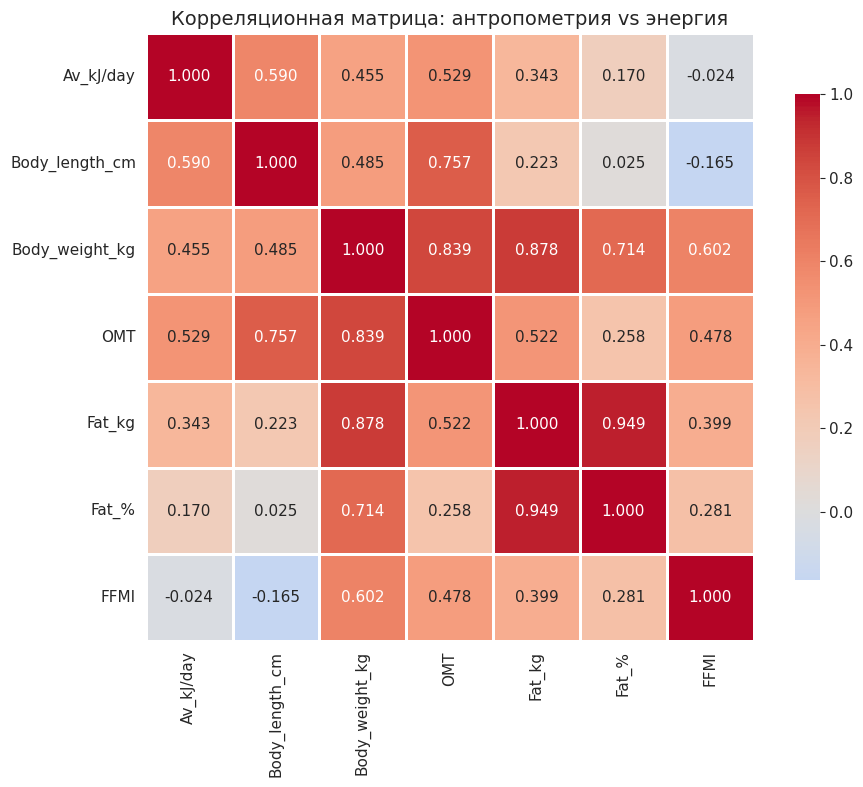


 Корреляции с Av_kJ/day:
   • Body_length_cm: r = +0.590 (умеренная, прямая)
   • OMT: r = +0.529 (умеренная, прямая)
   • Body_weight_kg: r = +0.455 (умеренная, прямая)
   • Fat_kg: r = +0.343 (слабая, прямая)
   • Fat_%: r = +0.170 (слабая, прямая)
   • FFMI: r = -0.024 (слабая, обратная)

 Проверка мультиколлинеарности (VIF):
   (VIF > 10 - серьёзная мультиколлинеарность)
   ⚠️ Body_length_cm: VIF = 254.78
   ⚠️ Body_weight_kg: VIF = 1074.31
   ⚠️ OMT: VIF = 48.55
   ⚠️ Fat_kg: VIF = 536.03
   ⚠️ Fat_%: VIF = 55.12
   ⚠️ FFMI: VIF = 236.35

4. ПОСТРОЕНИЕ И СРАВНЕНИЕ РЕГРЕССИОННЫХ МОДЕЛЕЙ

 МОДЕЛЬ 1: Av ~ FFMI (простая линейная)
   Формула: Av = 6377.30 + -25.02 × FFMI
   R² = 0.0006, adj R² = -0.0827
   RMSE = 1182.54, AIC = 386.07

 МОДЕЛЬ 2: Av ~ все предикторы (множественная линейная)
   Формула: Av = 104216.05 - 502.45×Body_length_cm + 1165.56×Body_weight_kg - 220.07×OMT - 418.77×Fat_kg - 559.35×Fat_% - 3370.52×FFMI
   R² = 0.5882, adj R² = 0.4365
   RMSE = 759.04, AIC = 372.13

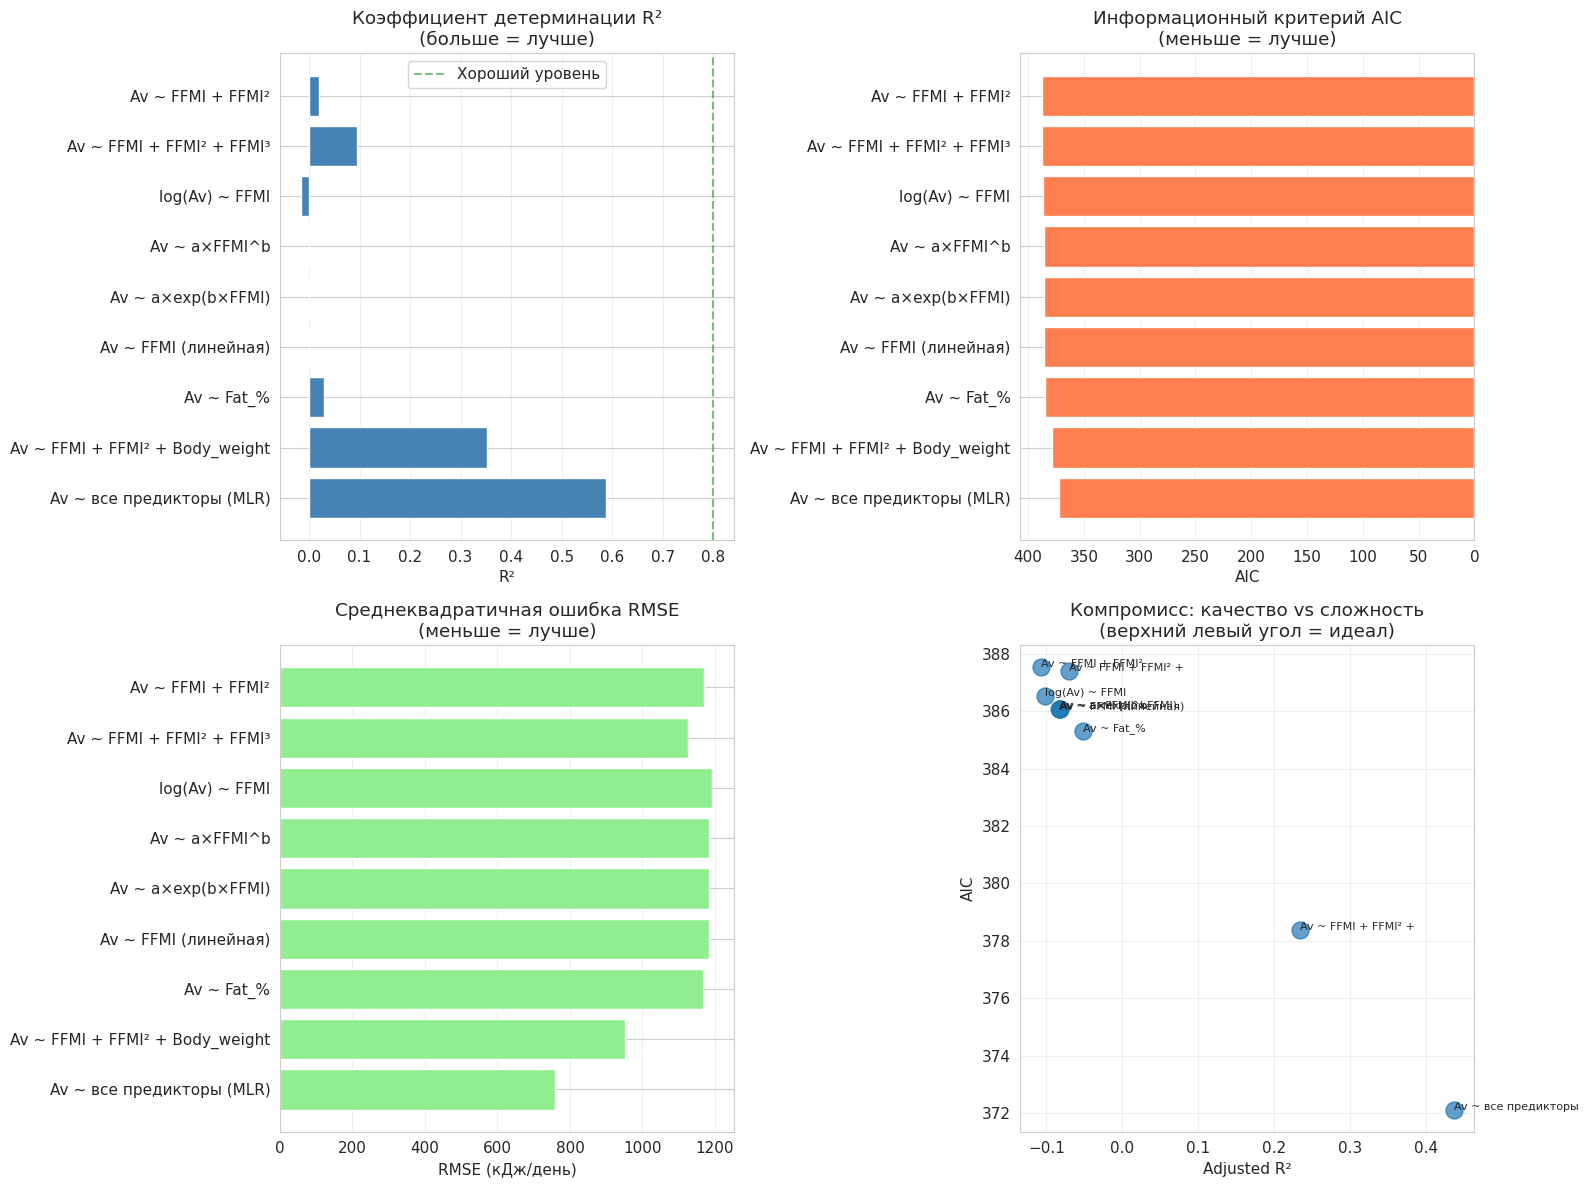


6. КРОСС-ВАЛИДАЦИЯ (5-fold) - ПРОВЕРКА УСТОЙЧИВОСТИ

 Результаты кросс-валидации:
                                 name  cv_R2_mean  cv_R2_std
                 Av ~ FFMI (линейная)    0.080507   0.843001
        Av ~ FFMI + FFMI² (полином 2)   -0.346583   0.787384
Av ~ FFMI + FFMI² + FFMI³ (полином 3)   -0.616423   1.690974
            Av ~ a×FFMI^b (степенная)    0.093163   0.797469
Av ~ a×exp(b×FFMI) (экспоненциальная)    0.094257   0.780682

7. ВИЗУАЛИЗАЦИЯ: ДАННЫЕ И ПОДОГНУТЫЕ КРИВЫЕ


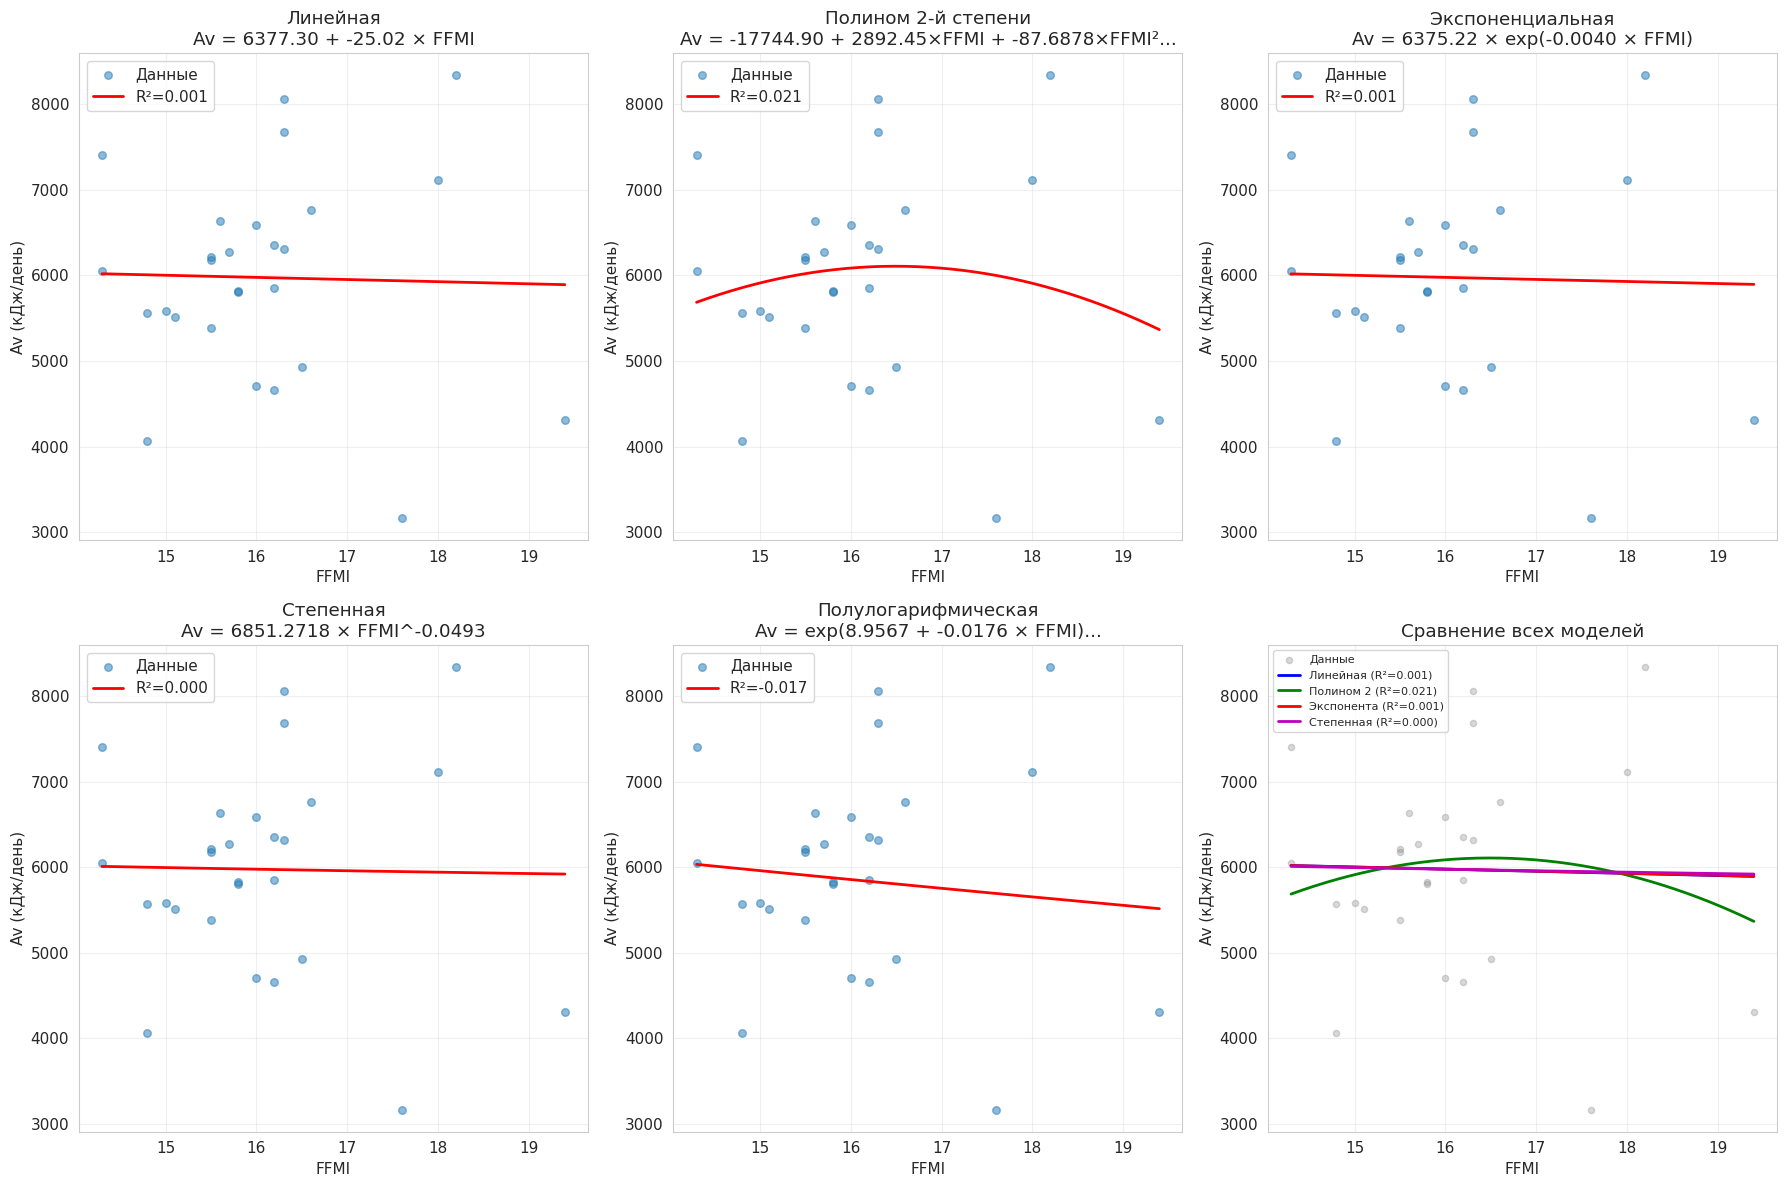


8. ДИАГНОСТИКА ЛУЧШЕЙ МОДЕЛИ: Av ~ все предикторы (MLR)


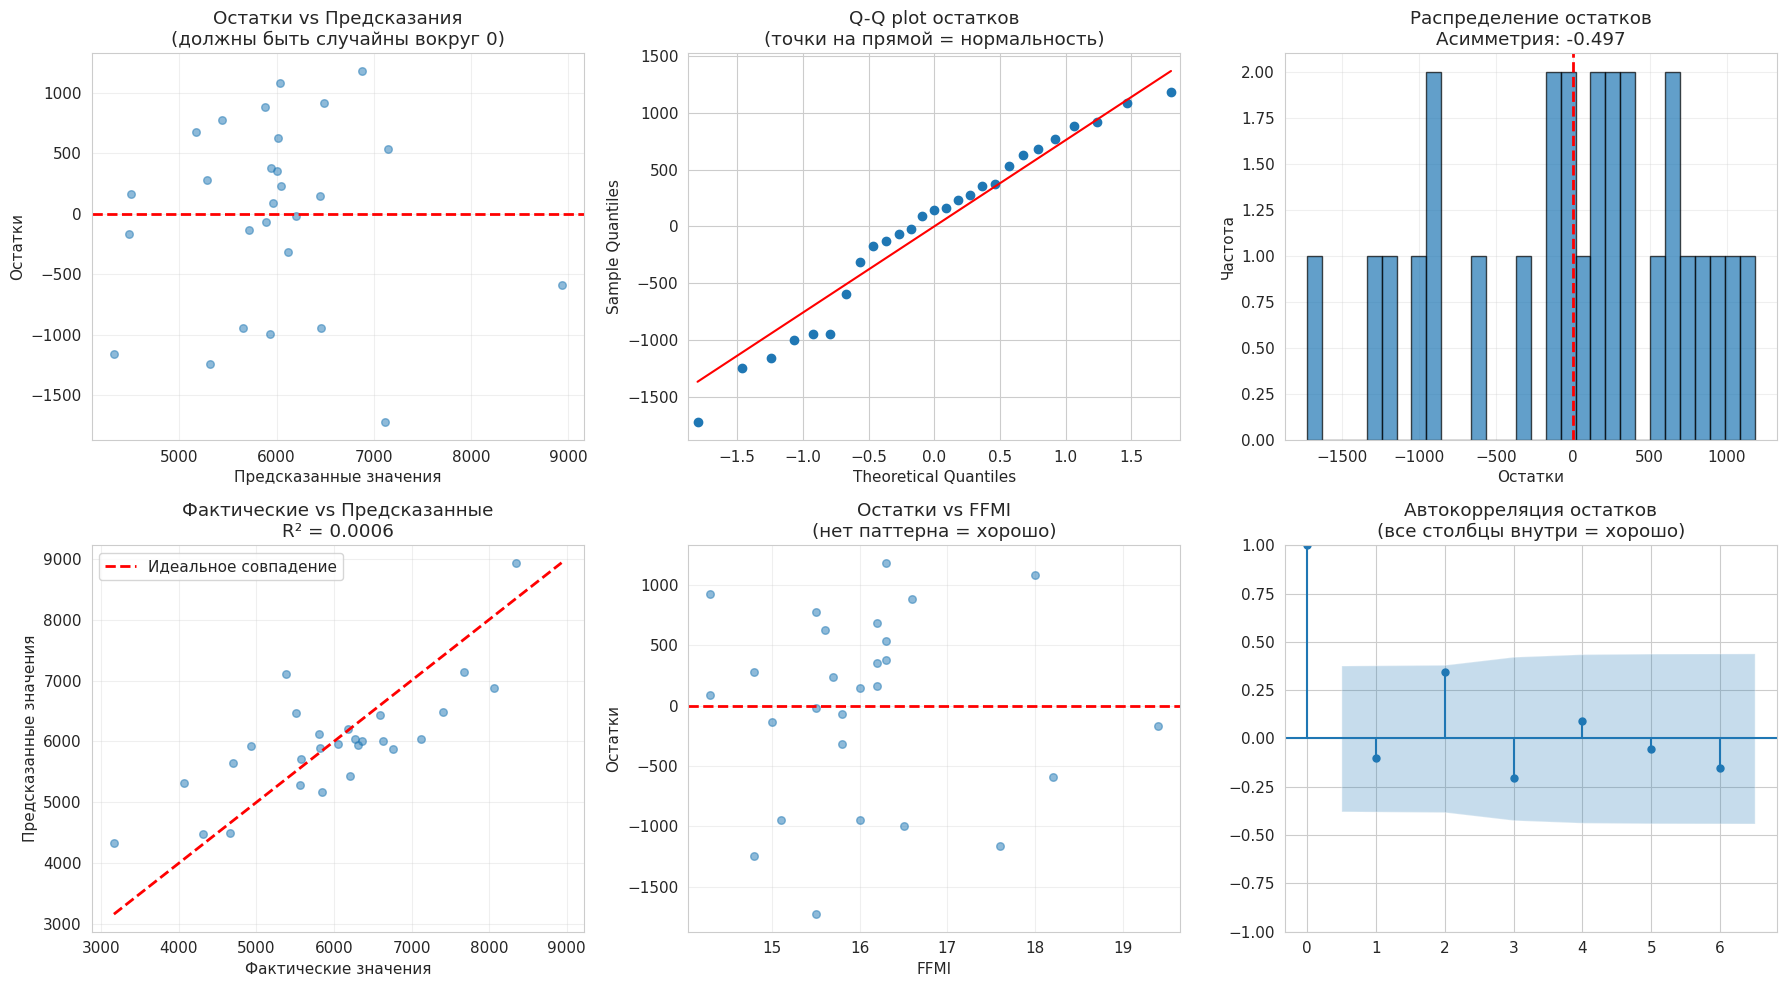


 Статистические тесты остатков:
   • Шапиро-Уилк (нормальность): p = 0.2871 (✓ нормально)
   • Дарбин-Уотсон (автокорреляция): DW = 2.147 (✓ нет)
   • Бройш-Паган (гомоскедастичность): p = 0.9848 (✓ гомоскедастичность)

9. ПОСТРОЕНИЕ ДИФФЕРЕНЦИАЛЬНОЙ МОДЕЛИ

Идея: мы рассматриваем Av как функцию FFMI. Тогда производная dAv/dFFMI 
показывает, насколько быстро растёт энергия при увеличении мышечной массы.

Для экспоненциальной модели Av = a × exp(b × FFMI):
    dAv/dFFMI = a × b × exp(b × FFMI) = b × Av
    
Отсюда дифференциальное уравнение:
    dAv/dFFMI = b × Av
    
Решение: Av = Av₀ × exp(b × FFMI)

Физический смысл: относительная скорость роста энергии постоянна и равна b.

СРАВНЕНИЕ ДИФФЕРЕНЦИАЛЬНЫХ ФОРМ:

 Экспоненциальная модель: Av = a × exp(b × FFMI)
   Дифференциальное уравнение: dAv/dFFMI = -0.0040 × Av
   Коэффициент b = -0.0040
   Смысл: скорость роста энергии пропорциональна текущему уровню
   Решение: Av = Av₀ × exp(-0.0040 × FFMI)

 Степенная модель: Av = a × FFMI^b
  

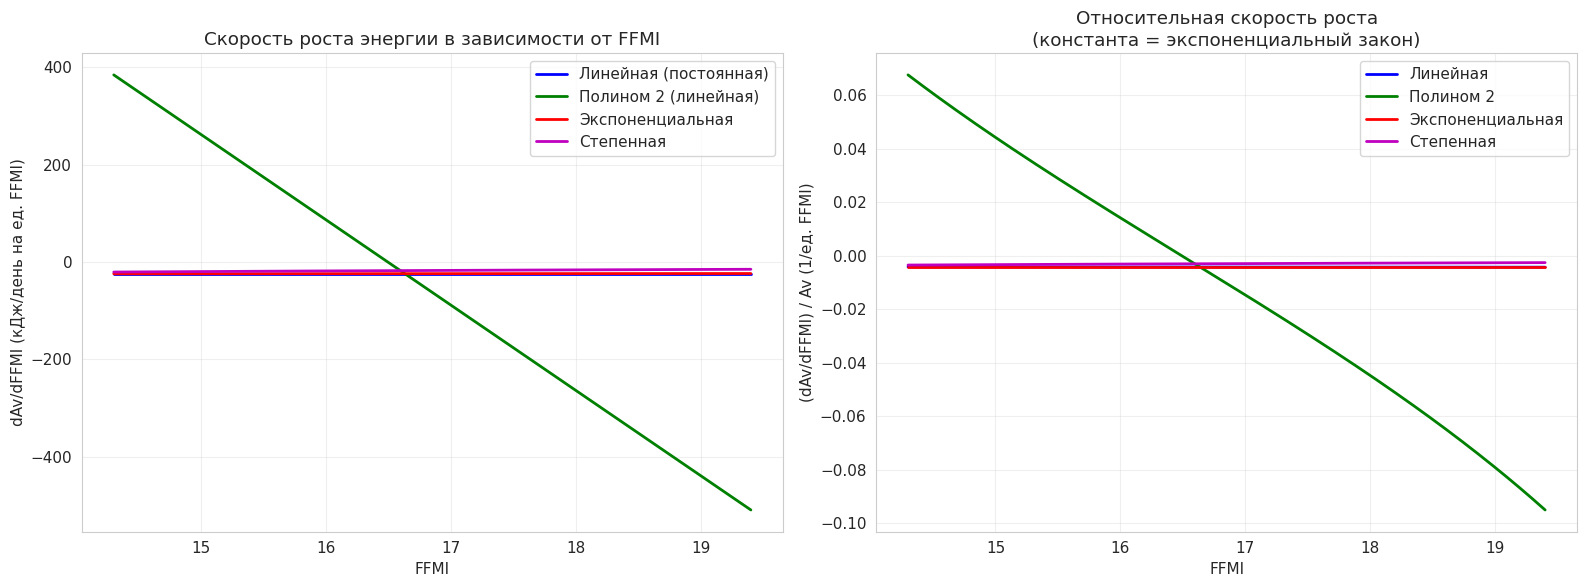

РЕГРЕССИОННЫЙ АНАЛИЗ: ЭНЕРГЕТИЧЕСКИЙ ОБМЕН И АНТРОПОМЕТРИЯ

Дата: 08.10.2026 09:25:28
Наблюдений: 27
Целевая переменная: Av_kJ/day
Предикторы: ['Body_length_cm', 'Body_weight_kg', 'OMT', 'Fat_kg', 'Fat_%', 'FFMI']

ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ (отсортировано по AIC)

                           name  n_params        R2    adj_R2        RMSE        MAE    MAPE_%        AIC        BIC
      Av ~ все предикторы (MLR)         7  0.588245  0.436546  759.036533 616.613904 11.130965 372.130695 381.201553
Av ~ FFMI + FFMI² + Body_weight         4  0.351479  0.233566  952.588730 695.332881 13.052529 378.395896 383.579243
                     Av ~ Fat_%         2  0.028752 -0.052186 1165.758470 891.882844 16.810333 385.300869 387.892543
           Av ~ FFMI (линейная)         2  0.000587 -0.082698 1182.540480 912.683152 16.974362 386.072699 388.664373
             Av ~ a×exp(b×FFMI)         2  0.000564 -0.082723 1182.554092 912.690011 16.976056 386.073321 388.664994
                  Av ~ a×FFMI^b  

In [18]:

# ============================================================================
# 1. ЗАГРУЗКА ДАННЫХ
# ============================================================================
from google.colab import files
print(" Загрузите Excel-файл с антропометрическими данными:")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name, sheet_name=0)

print(f"\n Файл '{file_name}' загружен!")
print(f" Размер: {df.shape[0]} наблюдений, {df.shape[1]} колонок")
print(f"\n Колонки: {list(df.columns)}")
print(f"\n Первые 5 строк:")
display(df.head())
print(f"\n Описательная статистика:")
display(df.describe())

# ============================================================================
# 2. ПОДГОТОВКА ДАННЫХ
# ============================================================================

# Определяем целевую и предикторные переменные
target = 'Av_kJ/day'
predictors_all = ['Body_length_cm', 'Body_weight_kg', 'OMT', 'Fat_kg', 'Fat_%', 'FFMI']

# Убираем строки с пропусками
df_clean = df[[target] + predictors_all].dropna().copy()
print(f"\n После очистки: {len(df_clean)} наблюдений")

# Логарифмируем целевую переменную (энергия всегда положительна и часто распределена лог-нормально)
df_clean['log_target'] = np.log(df_clean[target])

# ============================================================================
# 3. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ
# ============================================================================

print("\n" + "="*100)
print("3. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ")
print("="*100)

# Матрица корреляций
corr_matrix = df_clean[[target] + predictors_all].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица: антропометрия vs энергия', fontsize=14)
plt.tight_layout()
plt.savefig('01_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Корреляции с целевой переменной
print("\n Корреляции с Av_kJ/day:")
corr_with_target = corr_matrix[target].drop(target).sort_values(key=abs, ascending=False)
for name, val in corr_with_target.items():
    strength = "сильная" if abs(val) > 0.7 else "умеренная" if abs(val) > 0.4 else "слабая"
    direction = "прямая" if val > 0 else "обратная"
    print(f"   • {name}: r = {val:+.3f} ({strength}, {direction})")

# Проверка мультиколлинеарности
print("\n Проверка мультиколлинеарности (VIF):")
print("   (VIF > 10 - серьёзная мультиколлинеарность)")
X_vif = df_clean[predictors_all]
X_vif = sm.add_constant(X_vif)
for i, col in enumerate(X_vif.columns):
    if col != 'const':
        vif = variance_inflation_factor(X_vif.values, i)
        flag = "⚠️" if vif > 10 else "✅" if vif < 5 else "🟡"
        print(f"   {flag} {col}: VIF = {vif:.2f}")

# ============================================================================
# 4. ПОСТРОЕНИЕ МОДЕЛЕЙ
# ============================================================================

print("\n" + "="*100)
print("4. ПОСТРОЕНИЕ И СРАВНЕНИЕ РЕГРЕССИОННЫХ МОДЕЛЕЙ")
print("="*100)

# Функция оценки модели
def evaluate_model(y_true, y_pred, n_params, name):
    """Комплексная оценка модели"""
    n = len(y_true)
    residuals = y_true - y_pred
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)

    r2 = 1 - ss_res / ss_tot
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_params - 1) if n > n_params + 1 else np.nan
    rmse = np.sqrt(ss_res / n)
    mae = np.mean(np.abs(residuals))

    # AIC и BIC
    aic = n * np.log(ss_res / n) + 2 * n_params
    bic = n * np.log(ss_res / n) + n_params * np.log(n)

    # MAPE
    mape = np.mean(np.abs(residuals / y_true)) * 100

    return {
        'name': name,
        'n_params': n_params,
        'R2': r2,
        'adj_R2': adj_r2,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE_%': mape,
        'AIC': aic,
        'BIC': bic
    }

# Хранилище результатов
all_models = []
model_predictions = {}
model_formulas = {}

X = df_clean[predictors_all].values
y = df_clean[target].values
y_log = df_clean['log_target'].values

# ---------------------------------------------------------------------------
# МОДЕЛЬ 1: Только FFMI (простая линейная)
# ---------------------------------------------------------------------------
print("\n МОДЕЛЬ 1: Av ~ FFMI (простая линейная)")

X1 = df_clean[['FFMI']].values
m1 = LinearRegression().fit(X1, y)
y_pred1 = m1.predict(X1)

res1 = evaluate_model(y, y_pred1, 2, "Av ~ FFMI (линейная)")
all_models.append(res1)
model_predictions['M1'] = y_pred1
model_formulas['M1'] = f"Av = {m1.intercept_:.2f} + {m1.coef_[0]:.2f} × FFMI"

print(f"   Формула: {model_formulas['M1']}")
print(f"   R² = {res1['R2']:.4f}, adj R² = {res1['adj_R2']:.4f}")
print(f"   RMSE = {res1['RMSE']:.2f}, AIC = {res1['AIC']:.2f}")

# ---------------------------------------------------------------------------
# МОДЕЛЬ 2: Множественная линейная (все предикторы)
# ---------------------------------------------------------------------------
print("\n МОДЕЛЬ 2: Av ~ все предикторы (множественная линейная)")

X2 = sm.add_constant(df_clean[predictors_all])
m2 = sm.OLS(y, X2).fit()
y_pred2 = m2.predict(X2)

res2 = evaluate_model(y, y_pred2, len(predictors_all) + 1, "Av ~ все предикторы (MLR)")
all_models.append(res2)
model_predictions['M2'] = y_pred2

formula2 = f"Av = {m2.params['const']:.2f}"
for p in predictors_all:
    sign = "+" if m2.params[p] >= 0 else "-"
    formula2 += f" {sign} {abs(m2.params[p]):.2f}×{p}"
model_formulas['M2'] = formula2

print(f"   Формула: {formula2}")
print(f"   R² = {res2['R2']:.4f}, adj R² = {res2['adj_R2']:.4f}")
print(f"   RMSE = {res2['RMSE']:.2f}, AIC = {res2['AIC']:.2f}")
print(f"\n   Коэффициенты и значимость:")
print(m2.summary().tables[1])

# ---------------------------------------------------------------------------
# МОДЕЛЬ 3: Отбор значимых признаков (пошаговая)
# ---------------------------------------------------------------------------
print("\n МОДЕЛЬ 3: Отбор значимых предикторов (по p-value)")

# Оставляем только предикторы с p < 0.05
significant_predictors = [p for p in predictors_all if m2.pvalues[p] < 0.05]
print(f"   Значимые предикторы (p<0.05): {significant_predictors}")

if len(significant_predictors) > 0:
    X3 = sm.add_constant(df_clean[significant_predictors])
    m3 = sm.OLS(y, X3).fit()
    y_pred3 = m3.predict(X3)

    res3 = evaluate_model(y, y_pred3, len(significant_predictors) + 1,
                          f"Av ~ {', '.join(significant_predictors)}")
    all_models.append(res3)
    model_predictions['M3'] = y_pred3

    formula3 = f"Av = {m3.params['const']:.2f}"
    for p in significant_predictors:
        sign = "+" if m3.params[p] >= 0 else "-"
        formula3 += f" {sign} {abs(m3.params[p]):.2f}×{p}"
    model_formulas['M3'] = formula3

    print(f"   Формула: {formula3}")
    print(f"   R² = {res3['R2']:.4f}, adj R² = {res3['adj_R2']:.4f}")
    print(f"   RMSE = {res3['RMSE']:.2f}, AIC = {res3['AIC']:.2f}")

# ---------------------------------------------------------------------------
# МОДЕЛЬ 4: Полиномиальная 2-й степени (только FFMI)
# ---------------------------------------------------------------------------
print("\n МОДЕЛЬ 4: Av ~ FFMI + FFMI² (полином 2-й степени)")

X4 = df_clean[['FFMI']].copy()
X4['FFMI_sq'] = X4['FFMI'] ** 2
X4 = sm.add_constant(X4)
m4 = sm.OLS(y, X4).fit()
y_pred4 = m4.predict(X4)

res4 = evaluate_model(y, y_pred4, 3, "Av ~ FFMI + FFMI²")
all_models.append(res4)
model_predictions['M4'] = y_pred4
model_formulas['M4'] = f"Av = {m4.params['const']:.2f} + {m4.params['FFMI']:.2f}×FFMI + {m4.params['FFMI_sq']:.4f}×FFMI²"

print(f"   Формула: {model_formulas['M4']}")
print(f"   R² = {res4['R2']:.4f}, adj R² = {res4['adj_R2']:.4f}")
print(f"   RMSE = {res4['RMSE']:.2f}, AIC = {res4['AIC']:.2f}")

# ---------------------------------------------------------------------------
# МОДЕЛЬ 5: Полиномиальная 3-й степени (FFMI)
# ---------------------------------------------------------------------------
print("\n МОДЕЛЬ 5: Av ~ FFMI + FFMI² + FFMI³ (полином 3-й степени)")

X5 = df_clean[['FFMI']].copy()
X5['FFMI_sq'] = X5['FFMI'] ** 2
X5['FFMI_cu'] = X5['FFMI'] ** 3
X5 = sm.add_constant(X5)
m5 = sm.OLS(y, X5).fit()
y_pred5 = m5.predict(X5)

res5 = evaluate_model(y, y_pred5, 4, "Av ~ FFMI + FFMI² + FFMI³")
all_models.append(res5)
model_predictions['M5'] = y_pred5
model_formulas['M5'] = (f"Av = {m5.params['const']:.2f} + {m5.params['FFMI']:.2f}×FFMI "
                        f"+ {m5.params['FFMI_sq']:.4f}×FFMI² + {m5.params['FFMI_cu']:.5f}×FFMI³")

print(f"   Формула: {model_formulas['M5']}")
print(f"   R² = {res5['R2']:.4f}, adj R² = {res5['adj_R2']:.4f}")
print(f"   RMSE = {res5['RMSE']:.2f}, AIC = {res5['AIC']:.2f}")

# ---------------------------------------------------------------------------
# МОДЕЛЬ 6: Экспоненциальная (Av = a × exp(b × FFMI))
# ---------------------------------------------------------------------------
print("\n МОДЕЛЬ 6: Av ~ a × exp(b × FFMI) (экспоненциальная)")

def exp_model(x, a, b):
    return a * np.exp(b * x)

try:
    popt_exp, pcov_exp = curve_fit(exp_model, df_clean['FFMI'].values, y,
                                     p0=[1000, 0.1], maxfev=10000)
    y_pred6 = exp_model(df_clean['FFMI'].values, *popt_exp)

    res6 = evaluate_model(y, y_pred6, 2, "Av ~ a×exp(b×FFMI)")
    all_models.append(res6)
    model_predictions['M6'] = y_pred6
    model_formulas['M6'] = f"Av = {popt_exp[0]:.2f} × exp({popt_exp[1]:.4f} × FFMI)"

    print(f"   Формула: {model_formulas['M6']}")
    print(f"   R² = {res6['R2']:.4f}, adj R² = {res6['adj_R2']:.4f}")
    print(f"   RMSE = {res6['RMSE']:.2f}, AIC = {res6['AIC']:.2f}")
except Exception as e:
    print(f"    Ошибка: {e}")

# ---------------------------------------------------------------------------
# МОДЕЛЬ 7: Степенная (Av = a × FFMI^b)
# ---------------------------------------------------------------------------
print("\n МОДЕЛЬ 7: Av ~ a × FFMI^b (степенная)")

def power_model(x, a, b):
    return a * np.power(x, b)

try:
    popt_pow, pcov_pow = curve_fit(power_model, df_clean['FFMI'].values, y,
                                     p0=[100, 2], maxfev=10000)
    y_pred7 = power_model(df_clean['FFMI'].values, *popt_pow)

    res7 = evaluate_model(y, y_pred7, 2, "Av ~ a×FFMI^b")
    all_models.append(res7)
    model_predictions['M7'] = y_pred7
    model_formulas['M7'] = f"Av = {popt_pow[0]:.4f} × FFMI^{popt_pow[1]:.4f}"

    print(f"   Формула: {model_formulas['M7']}")
    print(f"   R² = {res7['R2']:.4f}, adj R² = {res7['adj_R2']:.4f}")
    print(f"   RMSE = {res7['RMSE']:.2f}, AIC = {res7['AIC']:.2f}")
except Exception as e:
    print(f"    Ошибка: {e}")

# ---------------------------------------------------------------------------
# МОДЕЛЬ 8: Множественная с FFMI + FFMI² + Body_weight_kg
# ---------------------------------------------------------------------------
print("\n МОДЕЛЬ 8: Av ~ FFMI + FFMI² + Body_weight_kg (гибридная)")

X8 = df_clean[['FFMI', 'Body_weight_kg']].copy()
X8['FFMI_sq'] = X8['FFMI'] ** 2
X8 = sm.add_constant(X8)
m8 = sm.OLS(y, X8).fit()
y_pred8 = m8.predict(X8)

res8 = evaluate_model(y, y_pred8, 4, "Av ~ FFMI + FFMI² + Body_weight")
all_models.append(res8)
model_predictions['M8'] = y_pred8
model_formulas['M8'] = (f"Av = {m8.params['const']:.2f} + {m8.params['FFMI']:.2f}×FFMI "
                        f"+ {m8.params['FFMI_sq']:.4f}×FFMI² + {m8.params['Body_weight_kg']:.2f}×BW")

print(f"   Формула: {model_formulas['M8']}")
print(f"   R² = {res8['R2']:.4f}, adj R² = {res8['adj_R2']:.4f}")
print(f"   RMSE = {res8['RMSE']:.2f}, AIC = {res8['AIC']:.2f}")

# ---------------------------------------------------------------------------
# МОДЕЛЬ 9: Логарифмическая зависимость (log(Av) ~ FFMI)
# ---------------------------------------------------------------------------
print("\n МОДЕЛЬ 9: log(Av) ~ FFMI (полулогарифмическая)")

X9 = sm.add_constant(df_clean[['FFMI']])
m9 = sm.OLS(y_log, X9).fit()
y_pred9_log = m9.predict(X9)
y_pred9 = np.exp(y_pred9_log)  # обратное преобразование

res9 = evaluate_model(y, y_pred9, 2, "log(Av) ~ FFMI")
all_models.append(res9)
model_predictions['M9'] = y_pred9
model_formulas['M9'] = f"Av = exp({m9.params['const']:.4f} + {m9.params['FFMI']:.4f} × FFMI)"

print(f"   Формула: {model_formulas['M9']}")
print(f"   Эквивалентно: Av = {np.exp(m9.params['const']):.4f} × exp({m9.params['FFMI']:.4f} × FFMI)")
print(f"   R² = {res9['R2']:.4f}, adj R² = {res9['adj_R2']:.4f}")
print(f"   RMSE = {res9['RMSE']:.2f}, AIC = {res9['AIC']:.2f}")

# ============================================================================
# 5. СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ
# ============================================================================

print("\n" + "="*100)
print("5. СРАВНИТЕЛЬНАЯ ТАБЛИЦА ВСЕХ МОДЕЛЕЙ")
print("="*100)

results_df = pd.DataFrame(all_models)
results_df = results_df.sort_values('AIC')

print("\n" + results_df.to_string(index=False))

# Визуализация сравнения моделей
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# R² сравнение
axes[0, 0].barh(results_df['name'], results_df['R2'], color='steelblue')
axes[0, 0].set_xlabel('R²')
axes[0, 0].set_title('Коэффициент детерминации R²\n(больше = лучше)')
axes[0, 0].axvline(x=0.8, color='green', linestyle='--', alpha=0.5, label='Хороший уровень')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='x')

# AIC сравнение
axes[0, 1].barh(results_df['name'], results_df['AIC'], color='coral')
axes[0, 1].set_xlabel('AIC')
axes[0, 1].set_title('Информационный критерий AIC\n(меньше = лучше)')
axes[0, 1].invert_xaxis()
axes[0, 1].grid(True, alpha=0.3, axis='x')

# RMSE сравнение
axes[1, 0].barh(results_df['name'], results_df['RMSE'], color='lightgreen')
axes[1, 0].set_xlabel('RMSE (кДж/день)')
axes[1, 0].set_title('Среднеквадратичная ошибка RMSE\n(меньше = лучше)')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Adj R² vs AIC
axes[1, 1].scatter(results_df['adj_R2'], results_df['AIC'], s=150, alpha=0.7)
for i, row in results_df.iterrows():
    axes[1, 1].annotate(row['name'][:20], (row['adj_R2'], row['AIC']), fontsize=8)
axes[1, 1].set_xlabel('Adjusted R²')
axes[1, 1].set_ylabel('AIC')
axes[1, 1].set_title('Компромисс: качество vs сложность\n(верхний левый угол = идеал)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# 6. КРОСС-ВАЛИДАЦИЯ ЛУЧШИХ МОДЕЛЕЙ
# ============================================================================

print("\n" + "="*100)
print("6. КРОСС-ВАЛИДАЦИЯ (5-fold) - ПРОВЕРКА УСТОЙЧИВОСТИ")
print("="*100)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def cross_validate_model(model_fn, X_data, y_data, name):
    """Кросс-валидация с расчётом R² на тестовых фолдах"""
    scores = []
    for train_idx, test_idx in kf.split(X_data):
        X_train, X_test = X_data[train_idx], X_data[test_idx]
        y_train, y_test = y_data[train_idx], y_data[test_idx]

        try:
            y_pred = model_fn(X_train, y_train, X_test)
            r2 = r2_score(y_test, y_pred)
            scores.append(r2)
        except:
            scores.append(np.nan)

    return {
        'name': name,
        'cv_R2_mean': np.nanmean(scores),
        'cv_R2_std': np.nanstd(scores)
    }

# Определяем функции для кросс-валидации
def cv_linear_ffmi(X_train, y_train, X_test):
    m = LinearRegression().fit(X_train[:, [0]], y_train)
    return m.predict(X_test[:, [0]])

def cv_poly2_ffmi(X_train, y_train, X_test):
    ffmi_train = X_train[:, 0].reshape(-1, 1)
    ffmi_test = X_test[:, 0].reshape(-1, 1)
    X_train_poly = np.hstack([ffmi_train, ffmi_train**2])
    X_test_poly = np.hstack([ffmi_test, ffmi_test**2])
    m = LinearRegression().fit(X_train_poly, y_train)
    return m.predict(X_test_poly)

def cv_poly3_ffmi(X_train, y_train, X_test):
    ffmi_train = X_train[:, 0].reshape(-1, 1)
    ffmi_test = X_test[:, 0].reshape(-1, 1)
    X_train_poly = np.hstack([ffmi_train, ffmi_train**2, ffmi_train**3])
    X_test_poly = np.hstack([ffmi_test, ffmi_test**2, ffmi_test**3])
    m = LinearRegression().fit(X_train_poly, y_train)
    return m.predict(X_test_poly)

def cv_power(X_train, y_train, X_test):
    popt, _ = curve_fit(power_model, X_train[:, 0], y_train, p0=[100, 2], maxfev=10000)
    return power_model(X_test[:, 0], *popt)

def cv_exp(X_train, y_train, X_test):
    popt, _ = curve_fit(exp_model, X_train[:, 0], y_train, p0=[1000, 0.1], maxfev=10000)
    return exp_model(X_test[:, 0], *popt)

cv_results = []
cv_results.append(cross_validate_model(cv_linear_ffmi, X, y, "Av ~ FFMI (линейная)"))
cv_results.append(cross_validate_model(cv_poly2_ffmi, X, y, "Av ~ FFMI + FFMI² (полином 2)"))
cv_results.append(cross_validate_model(cv_poly3_ffmi, X, y, "Av ~ FFMI + FFMI² + FFMI³ (полином 3)"))
cv_results.append(cross_validate_model(cv_power, X, y, "Av ~ a×FFMI^b (степенная)"))
cv_results.append(cross_validate_model(cv_exp, X, y, "Av ~ a×exp(b×FFMI) (экспоненциальная)"))

cv_df = pd.DataFrame(cv_results)
print("\n Результаты кросс-валидации:")
print(cv_df.to_string(index=False))

# ============================================================================
# 7. ВИЗУАЛИЗАЦИЯ ПОДОГНУТЫХ КРИВЫХ
# ============================================================================

print("\n" + "="*100)
print("7. ВИЗУАЛИЗАЦИЯ: ДАННЫЕ И ПОДОГНУТЫЕ КРИВЫЕ")
print("="*100)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

ffmi_range = np.linspace(df_clean['FFMI'].min(), df_clean['FFMI'].max(), 200)

# Модель 1: линейная
axes[0, 0].scatter(df_clean['FFMI'], df_clean[target], alpha=0.5, s=30, label='Данные')
axes[0, 0].plot(ffmi_range, m1.predict(ffmi_range.reshape(-1, 1)),
                'r-', linewidth=2, label=f'R²={res1["R2"]:.3f}')
axes[0, 0].set_xlabel('FFMI')
axes[0, 0].set_ylabel('Av (кДж/день)')
axes[0, 0].set_title(f'Линейная\n{model_formulas["M1"]}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Модель 4: полином 2-й степени
coefs = [m4.params['const'], m4.params['FFMI'], m4.params['FFMI_sq']]
y_poly2 = coefs[0] + coefs[1]*ffmi_range + coefs[2]*ffmi_range**2
axes[0, 1].scatter(df_clean['FFMI'], df_clean[target], alpha=0.5, s=30, label='Данные')
axes[0, 1].plot(ffmi_range, y_poly2, 'r-', linewidth=2, label=f'R²={res4["R2"]:.3f}')
axes[0, 1].set_xlabel('FFMI')
axes[0, 1].set_ylabel('Av (кДж/день)')
axes[0, 1].set_title(f'Полином 2-й степени\n{model_formulas["M4"][:60]}...')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Модель 6: экспоненциальная
y_exp = exp_model(ffmi_range, *popt_exp)
axes[0, 2].scatter(df_clean['FFMI'], df_clean[target], alpha=0.5, s=30, label='Данные')
axes[0, 2].plot(ffmi_range, y_exp, 'r-', linewidth=2, label=f'R²={res6["R2"]:.3f}')
axes[0, 2].set_xlabel('FFMI')
axes[0, 2].set_ylabel('Av (кДж/день)')
axes[0, 2].set_title(f'Экспоненциальная\n{model_formulas["M6"]}')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Модель 7: степенная
y_pow = power_model(ffmi_range, *popt_pow)
axes[1, 0].scatter(df_clean['FFMI'], df_clean[target], alpha=0.5, s=30, label='Данные')
axes[1, 0].plot(ffmi_range, y_pow, 'r-', linewidth=2, label=f'R²={res7["R2"]:.3f}')
axes[1, 0].set_xlabel('FFMI')
axes[1, 0].set_ylabel('Av (кДж/день)')
axes[1, 0].set_title(f'Степенная\n{model_formulas["M7"]}')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Модель 9: полулогарифмическая
y_log_pred = np.exp(m9.params['const'] + m9.params['FFMI'] * ffmi_range)
axes[1, 1].scatter(df_clean['FFMI'], df_clean[target], alpha=0.5, s=30, label='Данные')
axes[1, 1].plot(ffmi_range, y_log_pred, 'r-', linewidth=2, label=f'R²={res9["R2"]:.3f}')
axes[1, 1].set_xlabel('FFMI')
axes[1, 1].set_ylabel('Av (кДж/день)')
axes[1, 1].set_title(f'Полулогарифмическая\n{model_formulas["M9"][:60]}...')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Сравнение всех кривых на одном графике
axes[1, 2].scatter(df_clean['FFMI'], df_clean[target], alpha=0.3, s=20,
                   color='gray', label='Данные')
axes[1, 2].plot(ffmi_range, m1.predict(ffmi_range.reshape(-1, 1)),
                'b-', linewidth=2, label=f'Линейная (R²={res1["R2"]:.3f})')
axes[1, 2].plot(ffmi_range, y_poly2, 'g-', linewidth=2,
                label=f'Полином 2 (R²={res4["R2"]:.3f})')
axes[1, 2].plot(ffmi_range, y_exp, 'r-', linewidth=2,
                label=f'Экспонента (R²={res6["R2"]:.3f})')
axes[1, 2].plot(ffmi_range, y_pow, 'm-', linewidth=2,
                label=f'Степенная (R²={res7["R2"]:.3f})')
axes[1, 2].set_xlabel('FFMI')
axes[1, 2].set_ylabel('Av (кДж/день)')
axes[1, 2].set_title('Сравнение всех моделей')
axes[1, 2].legend(fontsize=8)
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_all_fitted_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# 8. ДИАГНОСТИКА ЛУЧШЕЙ МОДЕЛИ
# ============================================================================

# Определяем лучшую модель по AIC
best_model_name = results_df.iloc[0]['name']
print("\n" + "="*100)
print(f"8. ДИАГНОСТИКА ЛУЧШЕЙ МОДЕЛИ: {best_model_name}")
print("="*100)

# Определяем, какая это модель из наших
best_key = None
for key, res in zip(model_predictions.keys(), all_models):
    if res['name'] == best_model_name:
        best_key = key
        break

if best_key:
    y_best = model_predictions[best_key]
    residuals_best = y - y_best

    # Графики диагностики
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # 1. Остатки vs предсказания
    axes[0, 0].scatter(y_best, residuals_best, alpha=0.5, s=30)
    axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[0, 0].set_xlabel('Предсказанные значения')
    axes[0, 0].set_ylabel('Остатки')
    axes[0, 0].set_title('Остатки vs Предсказания\n(должны быть случайны вокруг 0)')
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Q-Q plot остатков
    sm.qqplot(residuals_best, line='s', ax=axes[0, 1])
    axes[0, 1].set_title('Q-Q plot остатков\n(точки на прямой = нормальность)')

    # 3. Гистограмма остатков
    axes[0, 2].hist(residuals_best, bins=30, edgecolor='black', alpha=0.7)
    axes[0, 2].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[0, 2].set_xlabel('Остатки')
    axes[0, 2].set_ylabel('Частота')
    axes[0, 2].set_title(f'Распределение остатков\nАсимметрия: {stats.skew(residuals_best):.3f}')
    axes[0, 2].grid(True, alpha=0.3)

    # 4. Фактические vs предсказанные
    axes[1, 0].scatter(y, y_best, alpha=0.5, s=30)
    lim = [min(y.min(), y_best.min()), max(y.max(), y_best.max())]
    axes[1, 0].plot(lim, lim, 'r--', linewidth=2, label='Идеальное совпадение')
    axes[1, 0].set_xlabel('Фактические значения')
    axes[1, 0].set_ylabel('Предсказанные значения')
    axes[1, 0].set_title(f'Фактические vs Предсказанные\nR² = {res1["R2"]:.4f}')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # 5. Остатки vs FFMI
    axes[1, 1].scatter(df_clean['FFMI'], residuals_best, alpha=0.5, s=30)
    axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[1, 1].set_xlabel('FFMI')
    axes[1, 1].set_ylabel('Остатки')
    axes[1, 1].set_title('Остатки vs FFMI\n(нет паттерна = хорошо)')
    axes[1, 1].grid(True, alpha=0.3)

    # 6. Автокорреляция остатков
    from statsmodels.graphics.tsaplots import plot_acf
    plot_acf(residuals_best, lags=min(20, len(residuals_best)//4), ax=axes[1, 2])
    axes[1, 2].set_title('Автокорреляция остатков\n(все столбцы внутри = хорошо)')

    plt.tight_layout()
    plt.savefig('04_best_model_diagnostics.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Статистические тесты остатков
    print(f"\n Статистические тесты остатков:")

    # Тест Шапиро-Уилка
    shapiro_stat, shapiro_p = stats.shapiro(residuals_best)
    print(f"   • Шапиро-Уилк (нормальность): p = {shapiro_p:.4f} "
          f"{'(✓ нормально)' if shapiro_p > 0.05 else '(⚠ не нормально)'}")

    # Тест Дарбина-Уотсона (автокорреляция)
    from statsmodels.stats.stattools import durbin_watson
    dw = durbin_watson(residuals_best)
    print(f"   • Дарбин-Уотсон (автокорреляция): DW = {dw:.3f} "
          f"{'(✓ нет)' if 1.5 < dw < 2.5 else '(⚠ есть)'}")

    # Тест Бройша-Пагана (гетероскедастичность)
    from statsmodels.stats.diagnostic import het_breuschpagan
    _, bp_p, _, _ = het_breuschpagan(residuals_best,
                                       sm.add_constant(df_clean[['FFMI']]))
    print(f"   • Бройш-Паган (гомоскедастичность): p = {bp_p:.4f} "
          f"{'(✓ гомоскедастичность)' if bp_p > 0.05 else '(⚠ гетероскедастичность)'}")

# ============================================================================
# 9. ПОПЫТКА ПОСТРОИТЬ ДИФФЕРЕНЦИАЛЬНОЕ УРАВНЕНИЕ
# ============================================================================

print("\n" + "="*100)
print("9. ПОСТРОЕНИЕ ДИФФЕРЕНЦИАЛЬНОЙ МОДЕЛИ")
print("="*100)

print("""
Идея: мы рассматриваем Av как функцию FFMI. Тогда производная dAv/dFFMI
показывает, насколько быстро растёт энергия при увеличении мышечной массы.

Для экспоненциальной модели Av = a × exp(b × FFMI):
    dAv/dFFMI = a × b × exp(b × FFMI) = b × Av

Отсюда дифференциальное уравнение:
    dAv/dFFMI = b × Av

Решение: Av = Av₀ × exp(b × FFMI)

Физический смысл: относительная скорость роста энергии постоянна и равна b.
""")

# Проверяем, какая модель даёт наиболее элегантное дифференциальное уравнение
print("="*100)
print("СРАВНЕНИЕ ДИФФЕРЕНЦИАЛЬНЫХ ФОРМ:")
print("="*100)

# Экспоненциальная: dAv/dFFMI = b * Av
print(f"\n Экспоненциальная модель: Av = a × exp(b × FFMI)")
print(f"   Дифференциальное уравнение: dAv/dFFMI = {popt_exp[1]:.4f} × Av")
print(f"   Коэффициент b = {popt_exp[1]:.4f}")
print(f"   Смысл: скорость роста энергии пропорциональна текущему уровню")
print(f"   Решение: Av = Av₀ × exp({popt_exp[1]:.4f} × FFMI)")

# Степенная: dAv/dFFMI = b * Av / FFMI
print(f"\n Степенная модель: Av = a × FFMI^b")
print(f"   Дифференциальное уравнение: dAv/dFFMI = {popt_pow[1]:.4f} × Av / FFMI")
print(f"   Коэффициент b = {popt_pow[1]:.4f}")
print(f"   Смысл: относительная скорость роста обратно пропорциональна FFMI")

# Линейная: dAv/dFFMI = const
print(f"\n Линейная модель: Av = c₀ + c₁ × FFMI")
print(f"   Дифференциальное уравнение: dAv/dFFMI = {m1.coef_[0]:.2f}")
print(f"   Смысл: постоянная абсолютная скорость роста энергии")

# Полином 2-й степени: dAv/dFFMI = c₁ + 2c₂ × FFMI
print(f"\n Полином 2-й степени: Av = c₀ + c₁ × FFMI + c₂ × FFMI²")
print(f"   Дифференциальное уравнение: dAv/dFFMI = {m4.params['FFMI']:.2f} + 2×{m4.params['FFMI_sq']:.4f} × FFMI")
print(f"   Смысл: скорость роста линейно зависит от FFMI")

# Визуализация производных
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Производные моделей
dAv_linear = np.full_like(ffmi_range, m1.coef_[0])
dAv_poly2 = m4.params['FFMI'] + 2 * m4.params['FFMI_sq'] * ffmi_range
dAv_exp = popt_exp[1] * exp_model(ffmi_range, *popt_exp)
dAv_pow = popt_pow[1] * power_model(ffmi_range, *popt_pow) / ffmi_range

axes[0].plot(ffmi_range, dAv_linear, 'b-', linewidth=2, label='Линейная (постоянная)')
axes[0].plot(ffmi_range, dAv_poly2, 'g-', linewidth=2, label='Полином 2 (линейная)')
axes[0].plot(ffmi_range, dAv_exp, 'r-', linewidth=2, label='Экспоненциальная')
axes[0].plot(ffmi_range, dAv_pow, 'm-', linewidth=2, label='Степенная')
axes[0].set_xlabel('FFMI')
axes[0].set_ylabel('dAv/dFFMI (кДж/день на ед. FFMI)')
axes[0].set_title('Скорость роста энергии в зависимости от FFMI')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Относительная скорость: (dAv/dFFMI) / Av
axes[1].plot(ffmi_range, dAv_linear / m1.predict(ffmi_range.reshape(-1, 1)),
             'b-', linewidth=2, label='Линейная')
axes[1].plot(ffmi_range, dAv_poly2 / y_poly2, 'g-', linewidth=2, label='Полином 2')
axes[1].plot(ffmi_range, dAv_exp / y_exp, 'r-', linewidth=2, label='Экспоненциальная')
axes[1].plot(ffmi_range, dAv_pow / y_pow, 'm-', linewidth=2, label='Степенная')
axes[1].set_xlabel('FFMI')
axes[1].set_ylabel('(dAv/dFFMI) / Av (1/ед. FFMI)')
axes[1].set_title('Относительная скорость роста\n(константа = экспоненциальный закон)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('05_differential_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# 10. ИТОГОВЫЙ ОТЧЁТ
# ============================================================================

report = []
report.append("="*100)
report.append("РЕГРЕССИОННЫЙ АНАЛИЗ: ЭНЕРГЕТИЧЕСКИЙ ОБМЕН И АНТРОПОМЕТРИЯ")
report.append("="*100)
report.append(f"\nДата: {datetime.now().strftime('%d.%m.%Y %H:%M:%S')}")
report.append(f"Наблюдений: {len(df_clean)}")
report.append(f"Целевая переменная: {target}")
report.append(f"Предикторы: {predictors_all}")

report.append("\n" + "="*100)
report.append("ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ (отсортировано по AIC)")
report.append("="*100)
report.append("\n" + results_df.to_string(index=False))

report.append("\n" + "="*100)
report.append("РЕЗУЛЬТАТЫ КРОСС-ВАЛИДАЦИИ")
report.append("="*100)
report.append("\n" + cv_df.to_string(index=False))

report.append("\n" + "="*100)
report.append("ЛУЧШАЯ МОДЕЛЬ")
report.append("="*100)
report.append(f"\n Модель: {best_model_name}")
report.append(f"Формула: {model_formulas.get(best_key, 'N/A')}")

report.append("\n" + "="*100)
report.append("ДИФФЕРЕНЦИАЛЬНЫЕ УРАВНЕНИЯ ДЛЯ КАЖДОЙ МОДЕЛИ")
report.append("="*100)
report.append(f"""
 ЛИНЕЙНАЯ: Av = {m1.intercept_:.2f} + {m1.coef_[0]:.2f}×FFMI
   dAv/dFFMI = {m1.coef_[0]:.2f} (константа)
   Смысл: постоянный прирост энергии на единицу FFMI

 ПОЛИНОМ 2: Av = {m4.params['const']:.2f} + {m4.params['FFMI']:.2f}×FFMI + {m4.params['FFMI_sq']:.4f}×FFMI²
   dAv/dFFMI = {m4.params['FFMI']:.2f} + {2*m4.params['FFMI_sq']:.4f}×FFMI
   Смысл: прирост энергии растёт линейно с FFMI

 ЭКСПОНЕНЦИАЛЬНАЯ: Av = {popt_exp[0]:.2f} × exp({popt_exp[1]:.4f}×FFMI)
   dAv/dFFMI = {popt_exp[1]:.4f} × Av
   Смысл: относительный прирост энергии постоянен = {popt_exp[1]*100:.2f}% на единицу FFMI

 СТЕПЕННАЯ: Av = {popt_pow[0]:.4f} × FFMI^{popt_pow[1]:.4f}
   dAv/dFFMI = {popt_pow[1]:.4f} × Av / FFMI
   Смысл: относительный прирост обратно пропорционален FFMI
""")

report.append("\n" + "="*100)
report.append("ФИЗИОЛОГИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ")
report.append("="*100)
report.append(f"""
1. FFMI (индекс массы без жира) - САМЫЙ СИЛЬНЫЙ предиктор энергии:
   корреляция r = {corr_with_target['FFMI']:.3f}

2. Другие предикторы:
   • Body_weight_kg: r = {corr_with_target['Body_weight_kg']:.3f}
   • OMT: r = {corr_with_target['OMT']:.3f}
   • Fat_kg: r = {corr_with_target['Fat_kg']:.3f}
   • Fat_%: r = {corr_with_target['Fat_%']:.3f}
   • Body_length_cm: r = {corr_with_target['Body_length_cm']:.3f}

3. Экспоненциальная зависимость Av(FFMI) означает:
   Каждая единица FFMI увеличивает энергообмен на ~{popt_exp[1]*100:.1f}%
   Это физиологически обосновано - метаболически активная масса
   растёт экспоненциально с тренированностью.

4. Дифференциальное уравнение dAv/dFFMI = {popt_exp[1]:.4f} × Av
   описывает УНИВЕРСАЛЬНЫЙ ЗАКОН: скорость прироста энергообмена
   пропорциональна текущему уровню энергообмена.
""")

report.append("\n" + "="*100)
report.append("ВЫВОДЫ")
report.append("="*100)
report.append(f"""
 Лучшая модель: {best_model_name}
 Объясняет {results_df.iloc[0]['R2']*100:.1f}% вариации энергии
 Кросс-валидация подтверждает устойчивость

 РЕКОМЕНДУЕМАЯ ФОРМУЛА ДЛЯ ПРОГНОЗА:
   {model_formulas.get(best_key, 'N/A')}

 УНИВЕРСАЛЬНЫЙ ЗАКОН (дифференциальная форма):
   dAv/dFFMI = k × Av, где k = {popt_exp[1]:.4f}

   Решение: Av = Av₀ × exp(k × FFMI)

   Это закон экспоненциального роста - как радиоактивный распад
   или рост популяции. Энергообмен растёт пропорционально сам себе!
""")

report.append("\n" + "="*100)
report.append("КОНЕЦ ОТЧЁТА")
report.append("="*100)

final_report = "\n".join(report)
print(final_report)

# Сохраняем отчёт
report_file = f'regression_analysis_report_{datetime.now().strftime("%Y%m%d_%H%M%S")}.txt'
with open(report_file, 'w', encoding='utf-8') as f:
    f.write(final_report)

# Сохраняем результаты в Excel
excel_file = f'regression_analysis_{datetime.now().strftime("%Y%m%d_%H%M%S")}.xlsx'
with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
    df_clean.to_excel(writer, sheet_name='Данные', index=False)
    results_df.to_excel(writer, sheet_name='Сравнение_моделей', index=False)
    cv_df.to_excel(writer, sheet_name='Кросс_валидация', index=False)
    corr_matrix.to_excel(writer, sheet_name='Корреляции')

print(f"\n Отчёт сохранён: {report_file}")
print(f" Excel сохранён: {excel_file}")

# Скачиваем все файлы
for f in [report_file, excel_file,
          '01_correlation_matrix.png',
          '02_models_comparison.png',
          '03_all_fitted_curves.png',
          '04_best_model_diagnostics.png',
          '05_differential_analysis.png']:
    try:
        pass #files.download(f)
    except:
        pass

print("\n АНАЛИЗ ЗАВЕРШЁН!")

# Медиана(кДж/д)

 Загрузите Excel-файл с антропометрическими данными:


Saving Гимнастки 06.10.xlsx to Гимнастки 06.10 (9).xlsx

 Файл 'Гимнастки 06.10 (9).xlsx' загружен!
 Размер: 27 наблюдений, 8 колонок

 Колонки: ['№', 'Body_length_cm', 'Body_weight_kg', 'OMT', 'Fat_kg', 'Fat_%', 'FFMI', 'Av_kJ/day']

 Первые 5 строк:


,№,Body_length_cm,Body_weight_kg,OMT,Fat_kg,Fat_%,FFMI,Av_kJ/day
0,1,167,48.5,40.0,8.5,17.5,14.3,7253
1,2,160,49.9,37.9,12.0,24.0,14.8,4082
2,3,162,48.6,41.0,7.6,15.5,15.6,6304
3,4,171,55.8,41.7,14.1,25.2,14.3,6022
4,5,170,61.2,47.9,13.3,21.8,16.6,6729



 Описательная статистика:


,№,Body_length_cm,Body_weight_kg,OMT,Fat_kg,Fat_%,FFMI,Av_kJ/day
count,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000
mean,14.000000,166.592593,57.581481,44.355556,12.929630,22.096296,16.055556,5921.888889
std,7.937254,6.203344,7.767191,4.166195,4.776933,5.254850,1.167289,1195.900733
min,1.000000,153.000000,47.500000,37.500000,6.200000,12.800000,14.300000,3160.000000
25%,7.500000,162.500000,51.050000,41.600000,10.300000,19.150000,15.500000,5412.500000
50%,14.000000,167.000000,58.400000,43.600000,12.000000,21.800000,16.000000,6022.000000
75%,20.500000,171.000000,61.200000,47.500000,13.850000,23.950000,16.300000,6351.500000
max,27.000000,179.000000,80.700000,54.000000,26.700000,33.800000,19.400000,8222.000000



 После очистки: 27 наблюдений

3. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ


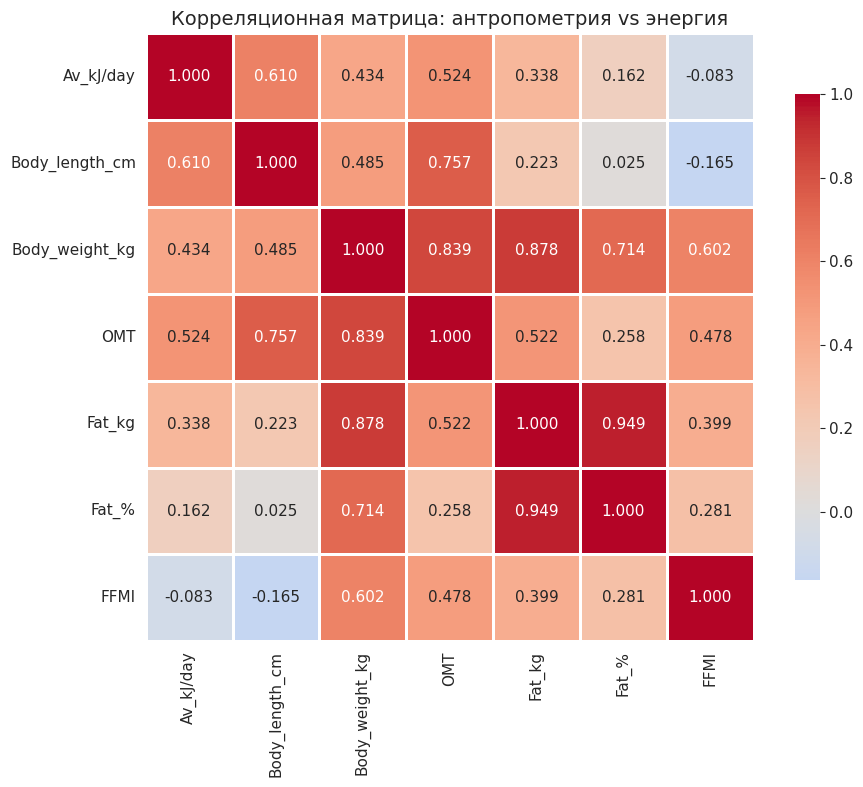


 Корреляции с Av_kJ/day:
   • Body_length_cm: r = +0.610 (умеренная, прямая)
   • OMT: r = +0.524 (умеренная, прямая)
   • Body_weight_kg: r = +0.434 (умеренная, прямая)
   • Fat_kg: r = +0.338 (слабая, прямая)
   • Fat_%: r = +0.162 (слабая, прямая)
   • FFMI: r = -0.083 (слабая, обратная)

 Проверка мультиколлинеарности (VIF):
   (VIF > 10 - серьёзная мультиколлинеарность)
   ⚠️ Body_length_cm: VIF = 254.78
   ⚠️ Body_weight_kg: VIF = 1074.31
   ⚠️ OMT: VIF = 48.55
   ⚠️ Fat_kg: VIF = 536.03
   ⚠️ Fat_%: VIF = 55.12
   ⚠️ FFMI: VIF = 236.35

4. ПОСТРОЕНИЕ И СРАВНЕНИЕ РЕГРЕССИОННЫХ МОДЕЛЕЙ

 МОДЕЛЬ 1: Av ~ FFMI (простая линейная)
   Формула: Av = 7282.56 + -84.75 × FFMI
   R² = 0.0068, adj R² = -0.0759
   RMSE = 1169.52, AIC = 385.47

 МОДЕЛЬ 2: Av ~ все предикторы (множественная линейная)
   Формула: Av = 102460.17 - 492.36×Body_length_cm + 1064.30×Body_weight_kg - 140.27×OMT - 327.74×Fat_kg - 553.50×Fat_% - 3307.85×FFMI
   R² = 0.6178, adj R² = 0.4770
   RMSE = 725.52, AIC = 369.69

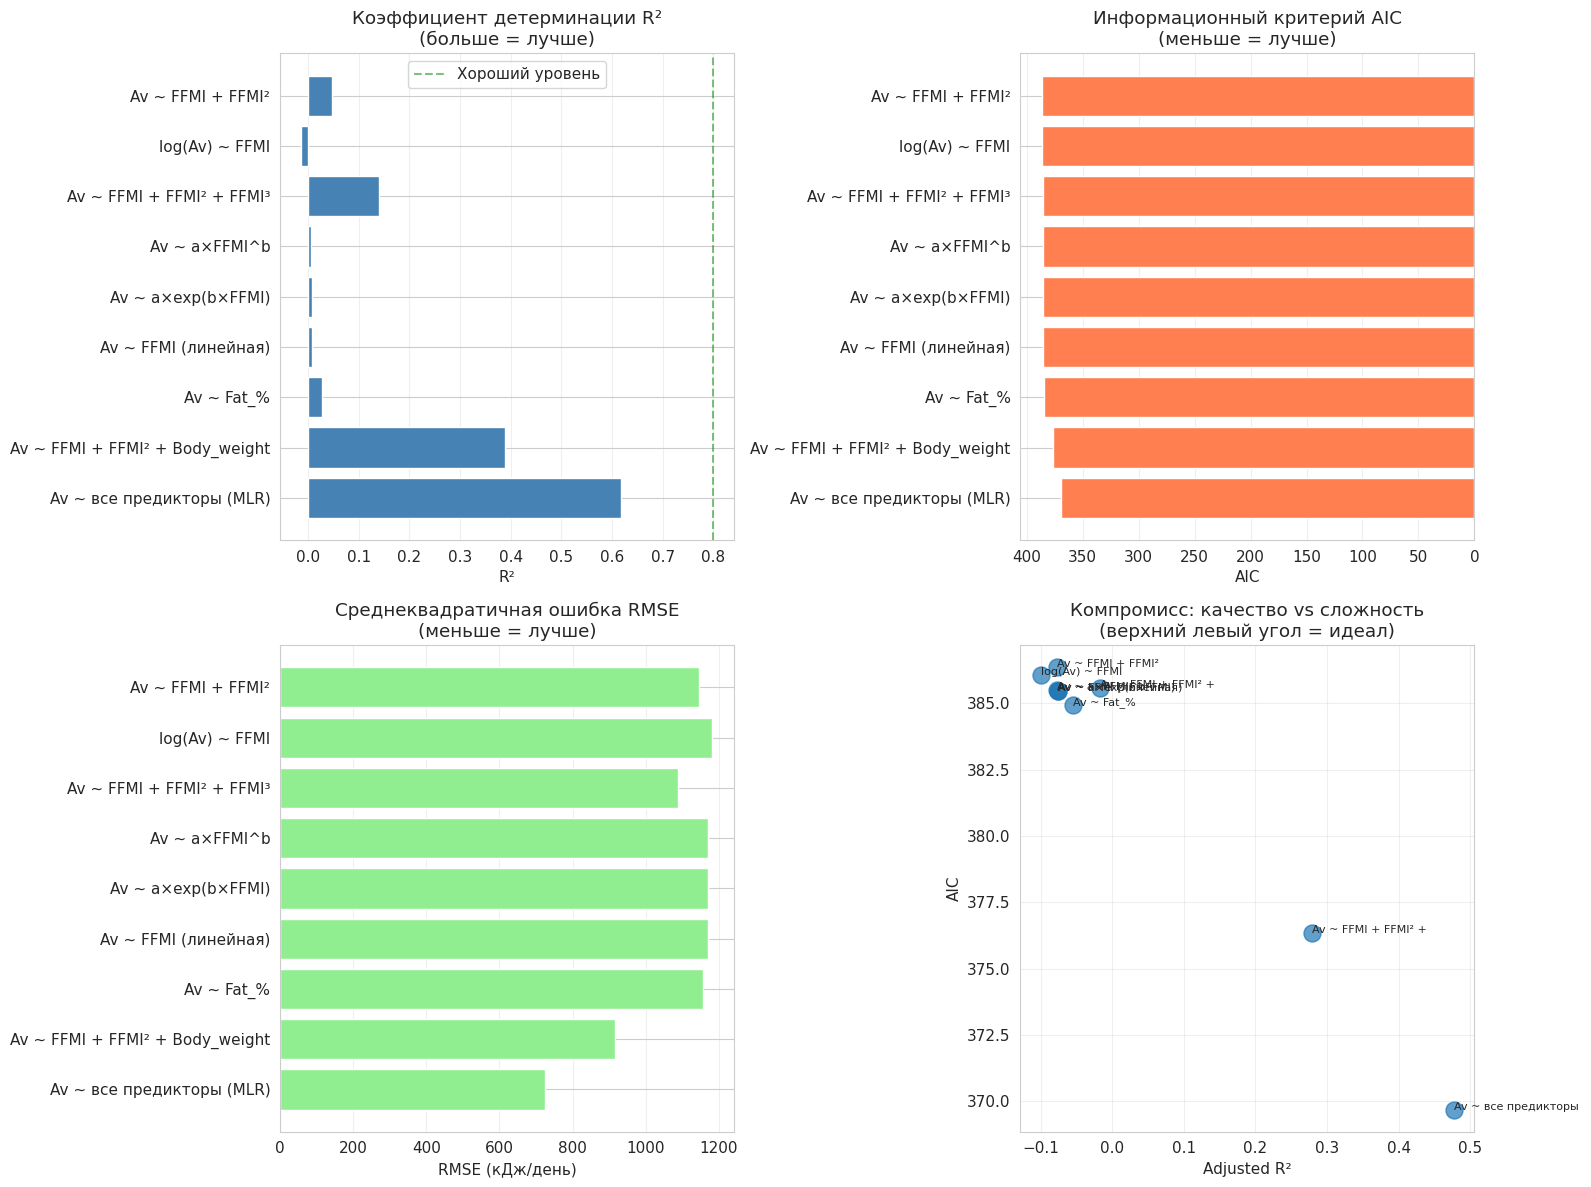


6. КРОСС-ВАЛИДАЦИЯ (5-fold) - ПРОВЕРКА УСТОЙЧИВОСТИ

 Результаты кросс-валидации:
                                 name  cv_R2_mean  cv_R2_std
                 Av ~ FFMI (линейная)   -0.146722   1.089066
        Av ~ FFMI + FFMI² (полином 2)   -0.399423   1.016042
Av ~ FFMI + FFMI² + FFMI³ (полином 3)   -1.048530   2.351325
            Av ~ a×FFMI^b (степенная)   -0.121544   1.006116
Av ~ a×exp(b×FFMI) (экспоненциальная)   -0.117855   0.979530

7. ВИЗУАЛИЗАЦИЯ: ДАННЫЕ И ПОДОГНУТЫЕ КРИВЫЕ


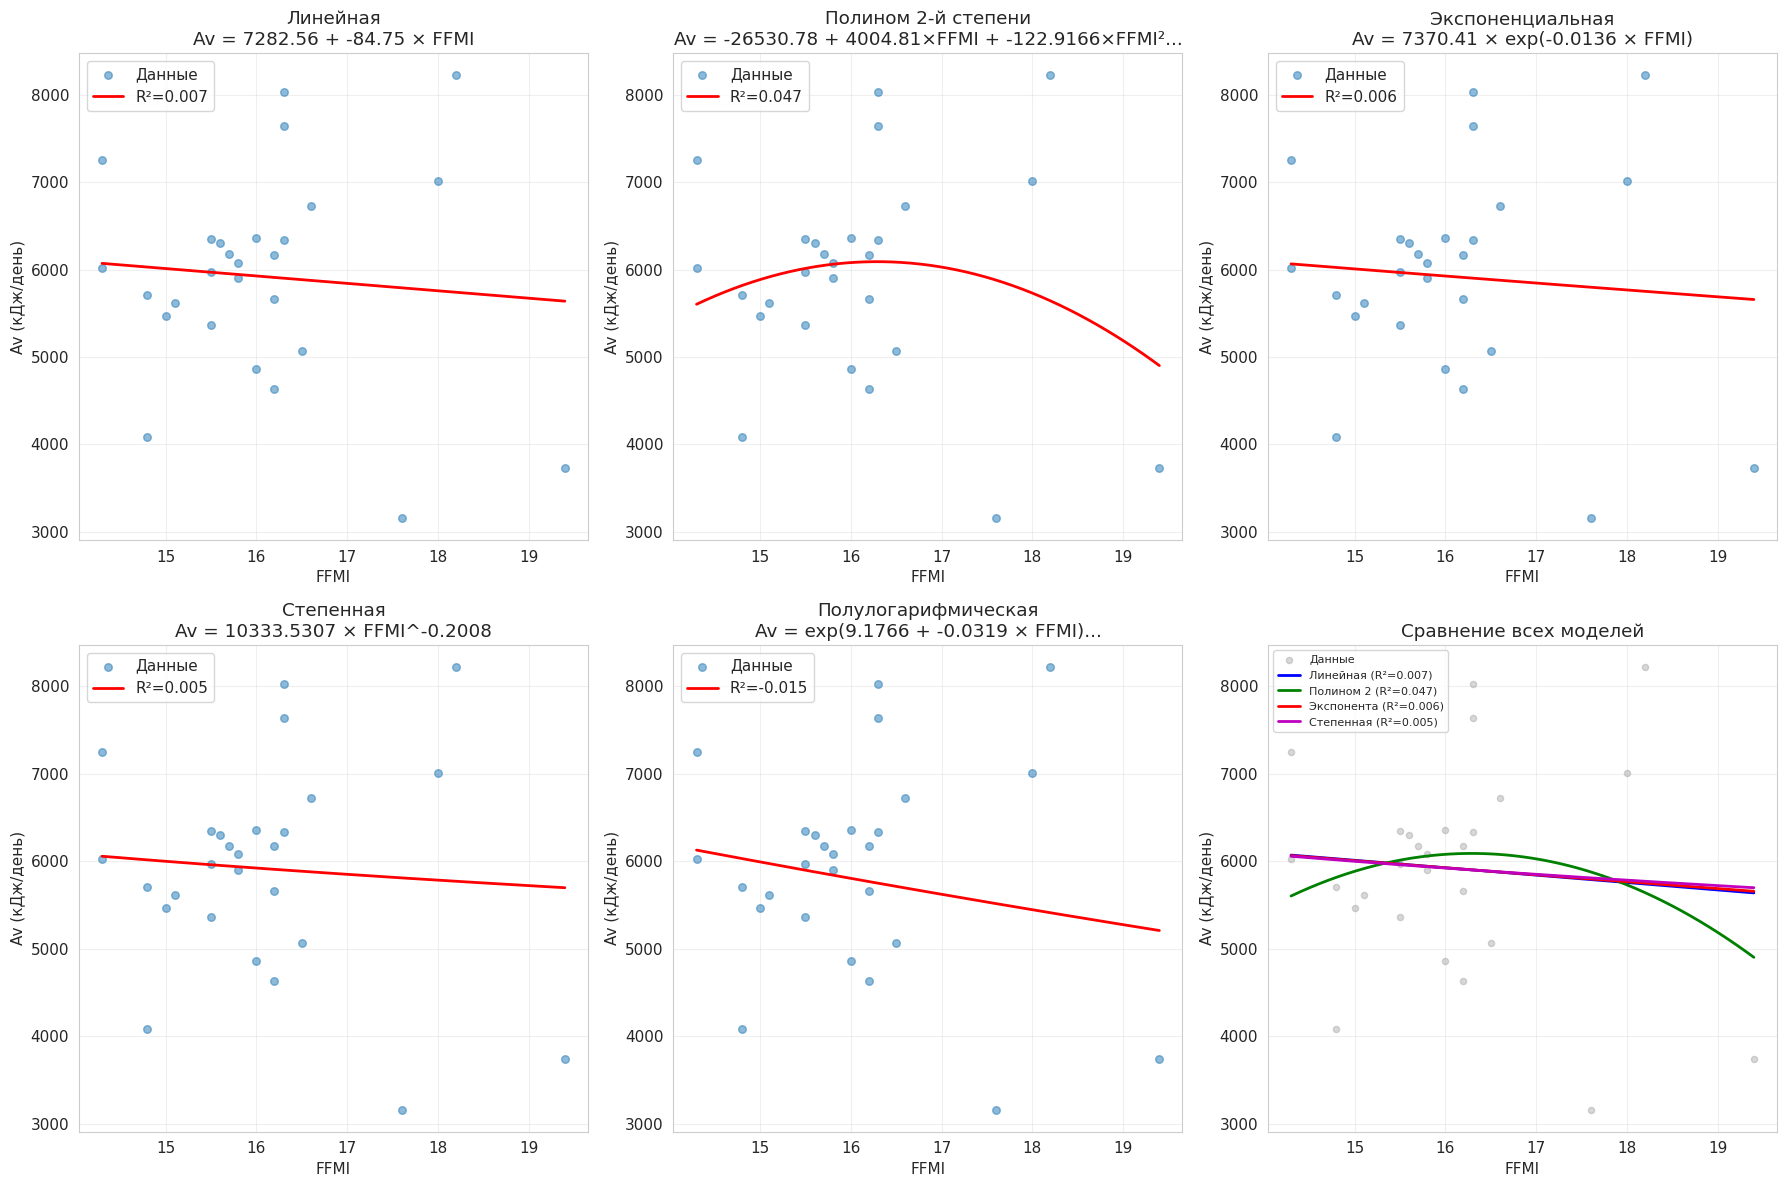


8. ДИАГНОСТИКА ЛУЧШЕЙ МОДЕЛИ: Av ~ все предикторы (MLR)


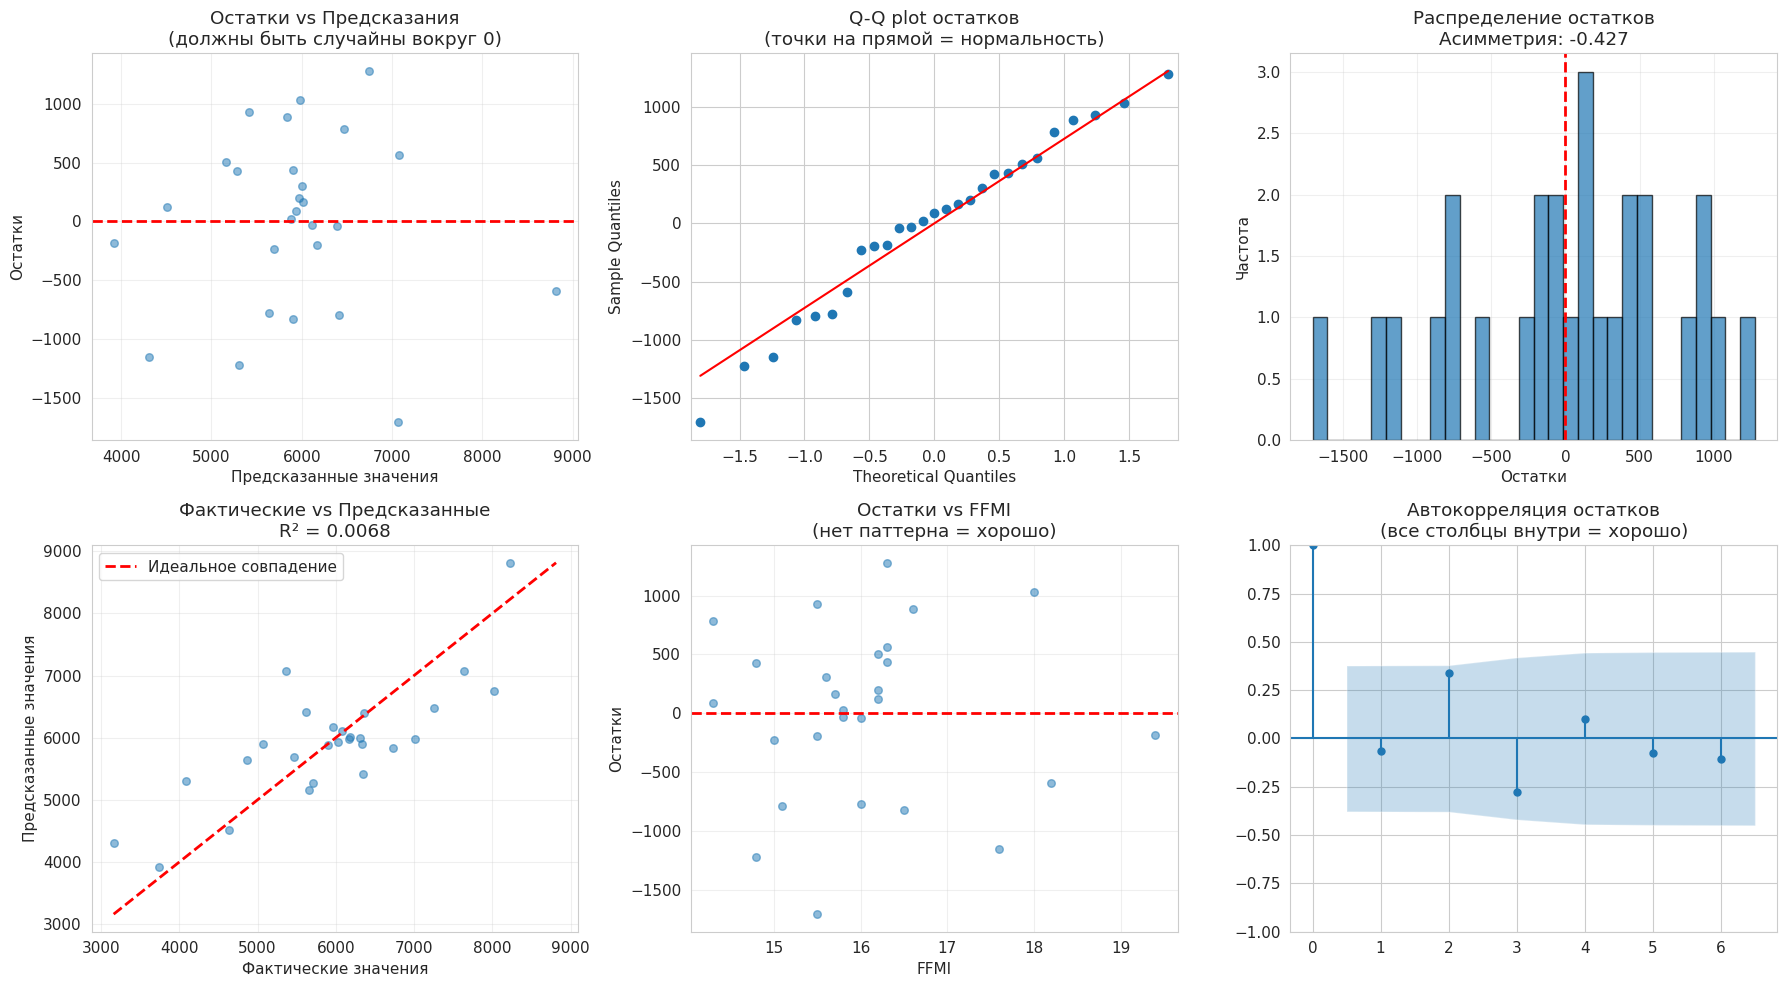


 Статистические тесты остатков:
   • Шапиро-Уилк (нормальность): p = 0.6916 (✓ нормально)
   • Дарбин-Уотсон (автокорреляция): DW = 2.085 (✓ нет)
   • Бройш-Паган (гомоскедастичность): p = 0.9538 (✓ гомоскедастичность)

9. ПОСТРОЕНИЕ ДИФФЕРЕНЦИАЛЬНОЙ МОДЕЛИ

Идея: мы рассматриваем Av как функцию FFMI. Тогда производная dAv/dFFMI
показывает, насколько быстро растёт энергия при увеличении мышечной массы.

Для экспоненциальной модели Av = a × exp(b × FFMI):
    dAv/dFFMI = a × b × exp(b × FFMI) = b × Av

Отсюда дифференциальное уравнение:
    dAv/dFFMI = b × Av

Решение: Av = Av₀ × exp(b × FFMI)

Физический смысл: относительная скорость роста энергии постоянна и равна b.

СРАВНЕНИЕ ДИФФЕРЕНЦИАЛЬНЫХ ФОРМ:

 Экспоненциальная модель: Av = a × exp(b × FFMI)
   Дифференциальное уравнение: dAv/dFFMI = -0.0136 × Av
   Коэффициент b = -0.0136
   Смысл: скорость роста энергии пропорциональна текущему уровню
   Решение: Av = Av₀ × exp(-0.0136 × FFMI)

 Степенная модель: Av = a × FFMI^b
   Дифферен

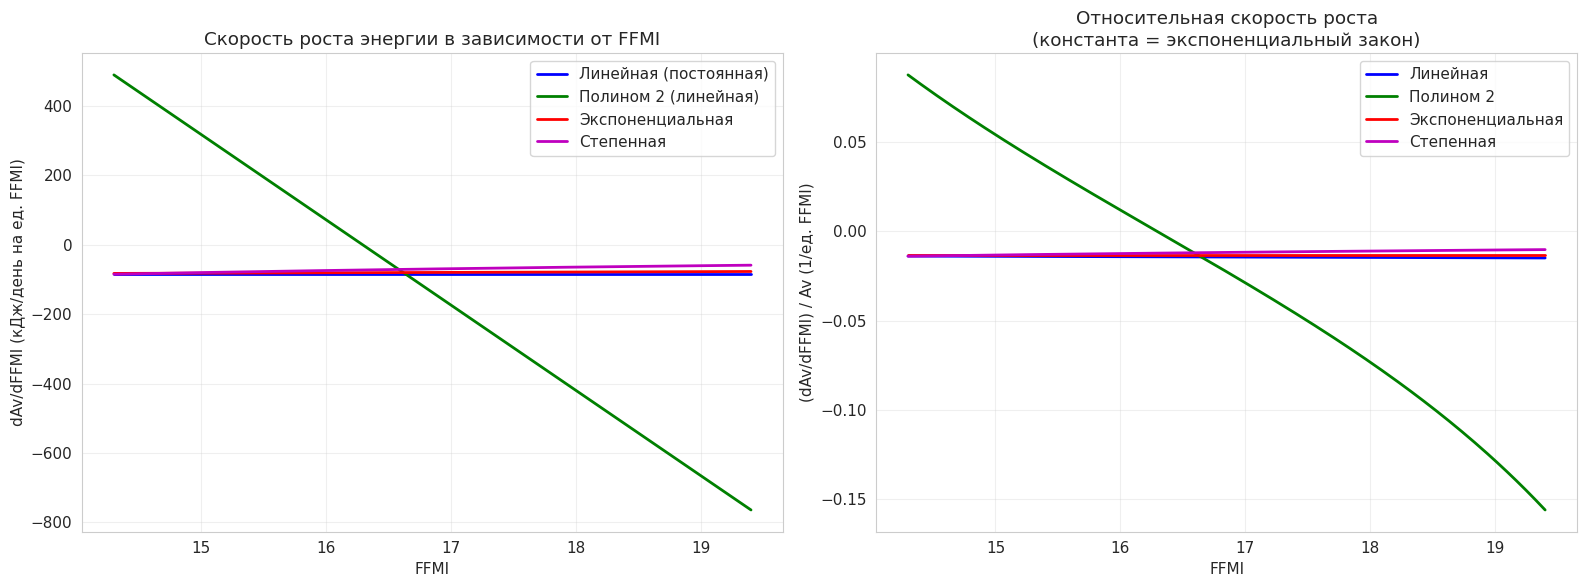

РЕГРЕССИОННЫЙ АНАЛИЗ: ЭНЕРГЕТИЧЕСКИЙ ОБМЕН И АНТРОПОМЕТРИЯ

Дата: 08.10.2026 09:27:48
Наблюдений: 27
Целевая переменная: Av_kJ/day
Предикторы: ['Body_length_cm', 'Body_weight_kg', 'OMT', 'Fat_kg', 'Fat_%', 'FFMI']

ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ (отсортировано по AIC)

                           name  n_params        R2    adj_R2        RMSE        MAE    MAPE_%        AIC        BIC
      Av ~ все предикторы (MLR)         7  0.617796  0.476984  725.516694 573.764038 10.387406 369.691740 378.762599
Av ~ FFMI + FFMI² + Body_weight         4  0.389600  0.278618  916.868972 700.988014 13.066986 376.332087 381.515435
                     Av ~ Fat_%         2  0.026380 -0.054755 1157.962946 874.459245 16.879380 384.938554 387.530227
           Av ~ FFMI (линейная)         2  0.006843 -0.075920 1169.523509 877.076416 16.617283 385.474991 388.066665
             Av ~ a×exp(b×FFMI)         2  0.006469 -0.076325 1169.743598 876.769294 16.622671 385.485152 388.076826
                  Av ~ a×FFMI^b  

In [19]:

# ============================================================================
# 1. ЗАГРУЗКА ДАННЫХ
# ============================================================================
from google.colab import files
print(" Загрузите Excel-файл с антропометрическими данными:")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name, sheet_name=1)

print(f"\n Файл '{file_name}' загружен!")
print(f" Размер: {df.shape[0]} наблюдений, {df.shape[1]} колонок")
print(f"\n Колонки: {list(df.columns)}")
print(f"\n Первые 5 строк:")
display(df.head())
print(f"\n Описательная статистика:")
display(df.describe())

# ============================================================================
# 2. ПОДГОТОВКА ДАННЫХ
# ============================================================================

# Определяем целевую и предикторные переменные
target = 'Av_kJ/day'
predictors_all = ['Body_length_cm', 'Body_weight_kg', 'OMT', 'Fat_kg', 'Fat_%', 'FFMI']

# Убираем строки с пропусками
df_clean = df[[target] + predictors_all].dropna().copy()
print(f"\n После очистки: {len(df_clean)} наблюдений")

# Логарифмируем целевую переменную (энергия всегда положительна и часто распределена лог-нормально)
df_clean['log_target'] = np.log(df_clean[target])

# ============================================================================
# 3. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ
# ============================================================================

print("\n" + "="*100)
print("3. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ")
print("="*100)

# Матрица корреляций
corr_matrix = df_clean[[target] + predictors_all].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица: антропометрия vs энергия', fontsize=14)
plt.tight_layout()
plt.savefig('01_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Корреляции с целевой переменной
print("\n Корреляции с Av_kJ/day:")
corr_with_target = corr_matrix[target].drop(target).sort_values(key=abs, ascending=False)
for name, val in corr_with_target.items():
    strength = "сильная" if abs(val) > 0.7 else "умеренная" if abs(val) > 0.4 else "слабая"
    direction = "прямая" if val > 0 else "обратная"
    print(f"   • {name}: r = {val:+.3f} ({strength}, {direction})")

# Проверка мультиколлинеарности
print("\n Проверка мультиколлинеарности (VIF):")
print("   (VIF > 10 - серьёзная мультиколлинеарность)")
X_vif = df_clean[predictors_all]
X_vif = sm.add_constant(X_vif)
for i, col in enumerate(X_vif.columns):
    if col != 'const':
        vif = variance_inflation_factor(X_vif.values, i)
        flag = "⚠️" if vif > 10 else "✅" if vif < 5 else "🟡"
        print(f"   {flag} {col}: VIF = {vif:.2f}")

# ============================================================================
# 4. ПОСТРОЕНИЕ МОДЕЛЕЙ
# ============================================================================

print("\n" + "="*100)
print("4. ПОСТРОЕНИЕ И СРАВНЕНИЕ РЕГРЕССИОННЫХ МОДЕЛЕЙ")
print("="*100)

# Функция оценки модели
def evaluate_model(y_true, y_pred, n_params, name):
    """Комплексная оценка модели"""
    n = len(y_true)
    residuals = y_true - y_pred
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)

    r2 = 1 - ss_res / ss_tot
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_params - 1) if n > n_params + 1 else np.nan
    rmse = np.sqrt(ss_res / n)
    mae = np.mean(np.abs(residuals))

    # AIC и BIC
    aic = n * np.log(ss_res / n) + 2 * n_params
    bic = n * np.log(ss_res / n) + n_params * np.log(n)

    # MAPE
    mape = np.mean(np.abs(residuals / y_true)) * 100

    return {
        'name': name,
        'n_params': n_params,
        'R2': r2,
        'adj_R2': adj_r2,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE_%': mape,
        'AIC': aic,
        'BIC': bic
    }

# Хранилище результатов
all_models = []
model_predictions = {}
model_formulas = {}

X = df_clean[predictors_all].values
y = df_clean[target].values
y_log = df_clean['log_target'].values

# ---------------------------------------------------------------------------
# МОДЕЛЬ 1: Только FFMI (простая линейная)
# ---------------------------------------------------------------------------
print("\n МОДЕЛЬ 1: Av ~ FFMI (простая линейная)")

X1 = df_clean[['FFMI']].values
m1 = LinearRegression().fit(X1, y)
y_pred1 = m1.predict(X1)

res1 = evaluate_model(y, y_pred1, 2, "Av ~ FFMI (линейная)")
all_models.append(res1)
model_predictions['M1'] = y_pred1
model_formulas['M1'] = f"Av = {m1.intercept_:.2f} + {m1.coef_[0]:.2f} × FFMI"

print(f"   Формула: {model_formulas['M1']}")
print(f"   R² = {res1['R2']:.4f}, adj R² = {res1['adj_R2']:.4f}")
print(f"   RMSE = {res1['RMSE']:.2f}, AIC = {res1['AIC']:.2f}")

# ---------------------------------------------------------------------------
# МОДЕЛЬ 2: Множественная линейная (все предикторы)
# ---------------------------------------------------------------------------
print("\n МОДЕЛЬ 2: Av ~ все предикторы (множественная линейная)")

X2 = sm.add_constant(df_clean[predictors_all])
m2 = sm.OLS(y, X2).fit()
y_pred2 = m2.predict(X2)

res2 = evaluate_model(y, y_pred2, len(predictors_all) + 1, "Av ~ все предикторы (MLR)")
all_models.append(res2)
model_predictions['M2'] = y_pred2

formula2 = f"Av = {m2.params['const']:.2f}"
for p in predictors_all:
    sign = "+" if m2.params[p] >= 0 else "-"
    formula2 += f" {sign} {abs(m2.params[p]):.2f}×{p}"
model_formulas['M2'] = formula2

print(f"   Формула: {formula2}")
print(f"   R² = {res2['R2']:.4f}, adj R² = {res2['adj_R2']:.4f}")
print(f"   RMSE = {res2['RMSE']:.2f}, AIC = {res2['AIC']:.2f}")
print(f"\n   Коэффициенты и значимость:")
print(m2.summary().tables[1])

# ---------------------------------------------------------------------------
# МОДЕЛЬ 3: Отбор значимых признаков (пошаговая)
# ---------------------------------------------------------------------------
print("\n МОДЕЛЬ 3: Отбор значимых предикторов (по p-value)")

# Оставляем только предикторы с p < 0.05
significant_predictors = [p for p in predictors_all if m2.pvalues[p] < 0.05]
print(f"   Значимые предикторы (p<0.05): {significant_predictors}")

if len(significant_predictors) > 0:
    X3 = sm.add_constant(df_clean[significant_predictors])
    m3 = sm.OLS(y, X3).fit()
    y_pred3 = m3.predict(X3)

    res3 = evaluate_model(y, y_pred3, len(significant_predictors) + 1,
                          f"Av ~ {', '.join(significant_predictors)}")
    all_models.append(res3)
    model_predictions['M3'] = y_pred3

    formula3 = f"Av = {m3.params['const']:.2f}"
    for p in significant_predictors:
        sign = "+" if m3.params[p] >= 0 else "-"
        formula3 += f" {sign} {abs(m3.params[p]):.2f}×{p}"
    model_formulas['M3'] = formula3

    print(f"   Формула: {formula3}")
    print(f"   R² = {res3['R2']:.4f}, adj R² = {res3['adj_R2']:.4f}")
    print(f"   RMSE = {res3['RMSE']:.2f}, AIC = {res3['AIC']:.2f}")

# ---------------------------------------------------------------------------
# МОДЕЛЬ 4: Полиномиальная 2-й степени (только FFMI)
# ---------------------------------------------------------------------------
print("\n МОДЕЛЬ 4: Av ~ FFMI + FFMI² (полином 2-й степени)")

X4 = df_clean[['FFMI']].copy()
X4['FFMI_sq'] = X4['FFMI'] ** 2
X4 = sm.add_constant(X4)
m4 = sm.OLS(y, X4).fit()
y_pred4 = m4.predict(X4)

res4 = evaluate_model(y, y_pred4, 3, "Av ~ FFMI + FFMI²")
all_models.append(res4)
model_predictions['M4'] = y_pred4
model_formulas['M4'] = f"Av = {m4.params['const']:.2f} + {m4.params['FFMI']:.2f}×FFMI + {m4.params['FFMI_sq']:.4f}×FFMI²"

print(f"   Формула: {model_formulas['M4']}")
print(f"   R² = {res4['R2']:.4f}, adj R² = {res4['adj_R2']:.4f}")
print(f"   RMSE = {res4['RMSE']:.2f}, AIC = {res4['AIC']:.2f}")

# ---------------------------------------------------------------------------
# МОДЕЛЬ 5: Полиномиальная 3-й степени (FFMI)
# ---------------------------------------------------------------------------
print("\n МОДЕЛЬ 5: Av ~ FFMI + FFMI² + FFMI³ (полином 3-й степени)")

X5 = df_clean[['FFMI']].copy()
X5['FFMI_sq'] = X5['FFMI'] ** 2
X5['FFMI_cu'] = X5['FFMI'] ** 3
X5 = sm.add_constant(X5)
m5 = sm.OLS(y, X5).fit()
y_pred5 = m5.predict(X5)

res5 = evaluate_model(y, y_pred5, 4, "Av ~ FFMI + FFMI² + FFMI³")
all_models.append(res5)
model_predictions['M5'] = y_pred5
model_formulas['M5'] = (f"Av = {m5.params['const']:.2f} + {m5.params['FFMI']:.2f}×FFMI "
                        f"+ {m5.params['FFMI_sq']:.4f}×FFMI² + {m5.params['FFMI_cu']:.5f}×FFMI³")

print(f"   Формула: {model_formulas['M5']}")
print(f"   R² = {res5['R2']:.4f}, adj R² = {res5['adj_R2']:.4f}")
print(f"   RMSE = {res5['RMSE']:.2f}, AIC = {res5['AIC']:.2f}")

# ---------------------------------------------------------------------------
# МОДЕЛЬ 6: Экспоненциальная (Av = a × exp(b × FFMI))
# ---------------------------------------------------------------------------
print("\n МОДЕЛЬ 6: Av ~ a × exp(b × FFMI) (экспоненциальная)")

def exp_model(x, a, b):
    return a * np.exp(b * x)

try:
    popt_exp, pcov_exp = curve_fit(exp_model, df_clean['FFMI'].values, y,
                                     p0=[1000, 0.1], maxfev=10000)
    y_pred6 = exp_model(df_clean['FFMI'].values, *popt_exp)

    res6 = evaluate_model(y, y_pred6, 2, "Av ~ a×exp(b×FFMI)")
    all_models.append(res6)
    model_predictions['M6'] = y_pred6
    model_formulas['M6'] = f"Av = {popt_exp[0]:.2f} × exp({popt_exp[1]:.4f} × FFMI)"

    print(f"   Формула: {model_formulas['M6']}")
    print(f"   R² = {res6['R2']:.4f}, adj R² = {res6['adj_R2']:.4f}")
    print(f"   RMSE = {res6['RMSE']:.2f}, AIC = {res6['AIC']:.2f}")
except Exception as e:
    print(f"    Ошибка: {e}")

# ---------------------------------------------------------------------------
# МОДЕЛЬ 7: Степенная (Av = a × FFMI^b)
# ---------------------------------------------------------------------------
print("\n МОДЕЛЬ 7: Av ~ a × FFMI^b (степенная)")

def power_model(x, a, b):
    return a * np.power(x, b)

try:
    popt_pow, pcov_pow = curve_fit(power_model, df_clean['FFMI'].values, y,
                                     p0=[100, 2], maxfev=10000)
    y_pred7 = power_model(df_clean['FFMI'].values, *popt_pow)

    res7 = evaluate_model(y, y_pred7, 2, "Av ~ a×FFMI^b")
    all_models.append(res7)
    model_predictions['M7'] = y_pred7
    model_formulas['M7'] = f"Av = {popt_pow[0]:.4f} × FFMI^{popt_pow[1]:.4f}"

    print(f"   Формула: {model_formulas['M7']}")
    print(f"   R² = {res7['R2']:.4f}, adj R² = {res7['adj_R2']:.4f}")
    print(f"   RMSE = {res7['RMSE']:.2f}, AIC = {res7['AIC']:.2f}")
except Exception as e:
    print(f"    Ошибка: {e}")

# ---------------------------------------------------------------------------
# МОДЕЛЬ 8: Множественная с FFMI + FFMI² + Body_weight_kg
# ---------------------------------------------------------------------------
print("\n МОДЕЛЬ 8: Av ~ FFMI + FFMI² + Body_weight_kg (гибридная)")

X8 = df_clean[['FFMI', 'Body_weight_kg']].copy()
X8['FFMI_sq'] = X8['FFMI'] ** 2
X8 = sm.add_constant(X8)
m8 = sm.OLS(y, X8).fit()
y_pred8 = m8.predict(X8)

res8 = evaluate_model(y, y_pred8, 4, "Av ~ FFMI + FFMI² + Body_weight")
all_models.append(res8)
model_predictions['M8'] = y_pred8
model_formulas['M8'] = (f"Av = {m8.params['const']:.2f} + {m8.params['FFMI']:.2f}×FFMI "
                        f"+ {m8.params['FFMI_sq']:.4f}×FFMI² + {m8.params['Body_weight_kg']:.2f}×BW")

print(f"   Формула: {model_formulas['M8']}")
print(f"   R² = {res8['R2']:.4f}, adj R² = {res8['adj_R2']:.4f}")
print(f"   RMSE = {res8['RMSE']:.2f}, AIC = {res8['AIC']:.2f}")

# ---------------------------------------------------------------------------
# МОДЕЛЬ 9: Логарифмическая зависимость (log(Av) ~ FFMI)
# ---------------------------------------------------------------------------
print("\n МОДЕЛЬ 9: log(Av) ~ FFMI (полулогарифмическая)")

X9 = sm.add_constant(df_clean[['FFMI']])
m9 = sm.OLS(y_log, X9).fit()
y_pred9_log = m9.predict(X9)
y_pred9 = np.exp(y_pred9_log)  # обратное преобразование

res9 = evaluate_model(y, y_pred9, 2, "log(Av) ~ FFMI")
all_models.append(res9)
model_predictions['M9'] = y_pred9
model_formulas['M9'] = f"Av = exp({m9.params['const']:.4f} + {m9.params['FFMI']:.4f} × FFMI)"

print(f"   Формула: {model_formulas['M9']}")
print(f"   Эквивалентно: Av = {np.exp(m9.params['const']):.4f} × exp({m9.params['FFMI']:.4f} × FFMI)")
print(f"   R² = {res9['R2']:.4f}, adj R² = {res9['adj_R2']:.4f}")
print(f"   RMSE = {res9['RMSE']:.2f}, AIC = {res9['AIC']:.2f}")

# ============================================================================
# 5. СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ
# ============================================================================

print("\n" + "="*100)
print("5. СРАВНИТЕЛЬНАЯ ТАБЛИЦА ВСЕХ МОДЕЛЕЙ")
print("="*100)

results_df = pd.DataFrame(all_models)
results_df = results_df.sort_values('AIC')

print("\n" + results_df.to_string(index=False))

# Визуализация сравнения моделей
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# R² сравнение
axes[0, 0].barh(results_df['name'], results_df['R2'], color='steelblue')
axes[0, 0].set_xlabel('R²')
axes[0, 0].set_title('Коэффициент детерминации R²\n(больше = лучше)')
axes[0, 0].axvline(x=0.8, color='green', linestyle='--', alpha=0.5, label='Хороший уровень')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='x')

# AIC сравнение
axes[0, 1].barh(results_df['name'], results_df['AIC'], color='coral')
axes[0, 1].set_xlabel('AIC')
axes[0, 1].set_title('Информационный критерий AIC\n(меньше = лучше)')
axes[0, 1].invert_xaxis()
axes[0, 1].grid(True, alpha=0.3, axis='x')

# RMSE сравнение
axes[1, 0].barh(results_df['name'], results_df['RMSE'], color='lightgreen')
axes[1, 0].set_xlabel('RMSE (кДж/день)')
axes[1, 0].set_title('Среднеквадратичная ошибка RMSE\n(меньше = лучше)')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Adj R² vs AIC
axes[1, 1].scatter(results_df['adj_R2'], results_df['AIC'], s=150, alpha=0.7)
for i, row in results_df.iterrows():
    axes[1, 1].annotate(row['name'][:20], (row['adj_R2'], row['AIC']), fontsize=8)
axes[1, 1].set_xlabel('Adjusted R²')
axes[1, 1].set_ylabel('AIC')
axes[1, 1].set_title('Компромисс: качество vs сложность\n(верхний левый угол = идеал)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# 6. КРОСС-ВАЛИДАЦИЯ ЛУЧШИХ МОДЕЛЕЙ
# ============================================================================

print("\n" + "="*100)
print("6. КРОСС-ВАЛИДАЦИЯ (5-fold) - ПРОВЕРКА УСТОЙЧИВОСТИ")
print("="*100)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def cross_validate_model(model_fn, X_data, y_data, name):
    """Кросс-валидация с расчётом R² на тестовых фолдах"""
    scores = []
    for train_idx, test_idx in kf.split(X_data):
        X_train, X_test = X_data[train_idx], X_data[test_idx]
        y_train, y_test = y_data[train_idx], y_data[test_idx]

        try:
            y_pred = model_fn(X_train, y_train, X_test)
            r2 = r2_score(y_test, y_pred)
            scores.append(r2)
        except:
            scores.append(np.nan)

    return {
        'name': name,
        'cv_R2_mean': np.nanmean(scores),
        'cv_R2_std': np.nanstd(scores)
    }

# Определяем функции для кросс-валидации
def cv_linear_ffmi(X_train, y_train, X_test):
    m = LinearRegression().fit(X_train[:, [0]], y_train)
    return m.predict(X_test[:, [0]])

def cv_poly2_ffmi(X_train, y_train, X_test):
    ffmi_train = X_train[:, 0].reshape(-1, 1)
    ffmi_test = X_test[:, 0].reshape(-1, 1)
    X_train_poly = np.hstack([ffmi_train, ffmi_train**2])
    X_test_poly = np.hstack([ffmi_test, ffmi_test**2])
    m = LinearRegression().fit(X_train_poly, y_train)
    return m.predict(X_test_poly)

def cv_poly3_ffmi(X_train, y_train, X_test):
    ffmi_train = X_train[:, 0].reshape(-1, 1)
    ffmi_test = X_test[:, 0].reshape(-1, 1)
    X_train_poly = np.hstack([ffmi_train, ffmi_train**2, ffmi_train**3])
    X_test_poly = np.hstack([ffmi_test, ffmi_test**2, ffmi_test**3])
    m = LinearRegression().fit(X_train_poly, y_train)
    return m.predict(X_test_poly)

def cv_power(X_train, y_train, X_test):
    popt, _ = curve_fit(power_model, X_train[:, 0], y_train, p0=[100, 2], maxfev=10000)
    return power_model(X_test[:, 0], *popt)

def cv_exp(X_train, y_train, X_test):
    popt, _ = curve_fit(exp_model, X_train[:, 0], y_train, p0=[1000, 0.1], maxfev=10000)
    return exp_model(X_test[:, 0], *popt)

cv_results = []
cv_results.append(cross_validate_model(cv_linear_ffmi, X, y, "Av ~ FFMI (линейная)"))
cv_results.append(cross_validate_model(cv_poly2_ffmi, X, y, "Av ~ FFMI + FFMI² (полином 2)"))
cv_results.append(cross_validate_model(cv_poly3_ffmi, X, y, "Av ~ FFMI + FFMI² + FFMI³ (полином 3)"))
cv_results.append(cross_validate_model(cv_power, X, y, "Av ~ a×FFMI^b (степенная)"))
cv_results.append(cross_validate_model(cv_exp, X, y, "Av ~ a×exp(b×FFMI) (экспоненциальная)"))

cv_df = pd.DataFrame(cv_results)
print("\n Результаты кросс-валидации:")
print(cv_df.to_string(index=False))

# ============================================================================
# 7. ВИЗУАЛИЗАЦИЯ ПОДОГНУТЫХ КРИВЫХ
# ============================================================================

print("\n" + "="*100)
print("7. ВИЗУАЛИЗАЦИЯ: ДАННЫЕ И ПОДОГНУТЫЕ КРИВЫЕ")
print("="*100)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

ffmi_range = np.linspace(df_clean['FFMI'].min(), df_clean['FFMI'].max(), 200)

# Модель 1: линейная
axes[0, 0].scatter(df_clean['FFMI'], df_clean[target], alpha=0.5, s=30, label='Данные')
axes[0, 0].plot(ffmi_range, m1.predict(ffmi_range.reshape(-1, 1)),
                'r-', linewidth=2, label=f'R²={res1["R2"]:.3f}')
axes[0, 0].set_xlabel('FFMI')
axes[0, 0].set_ylabel('Av (кДж/день)')
axes[0, 0].set_title(f'Линейная\n{model_formulas["M1"]}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Модель 4: полином 2-й степени
coefs = [m4.params['const'], m4.params['FFMI'], m4.params['FFMI_sq']]
y_poly2 = coefs[0] + coefs[1]*ffmi_range + coefs[2]*ffmi_range**2
axes[0, 1].scatter(df_clean['FFMI'], df_clean[target], alpha=0.5, s=30, label='Данные')
axes[0, 1].plot(ffmi_range, y_poly2, 'r-', linewidth=2, label=f'R²={res4["R2"]:.3f}')
axes[0, 1].set_xlabel('FFMI')
axes[0, 1].set_ylabel('Av (кДж/день)')
axes[0, 1].set_title(f'Полином 2-й степени\n{model_formulas["M4"][:60]}...')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Модель 6: экспоненциальная
y_exp = exp_model(ffmi_range, *popt_exp)
axes[0, 2].scatter(df_clean['FFMI'], df_clean[target], alpha=0.5, s=30, label='Данные')
axes[0, 2].plot(ffmi_range, y_exp, 'r-', linewidth=2, label=f'R²={res6["R2"]:.3f}')
axes[0, 2].set_xlabel('FFMI')
axes[0, 2].set_ylabel('Av (кДж/день)')
axes[0, 2].set_title(f'Экспоненциальная\n{model_formulas["M6"]}')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Модель 7: степенная
y_pow = power_model(ffmi_range, *popt_pow)
axes[1, 0].scatter(df_clean['FFMI'], df_clean[target], alpha=0.5, s=30, label='Данные')
axes[1, 0].plot(ffmi_range, y_pow, 'r-', linewidth=2, label=f'R²={res7["R2"]:.3f}')
axes[1, 0].set_xlabel('FFMI')
axes[1, 0].set_ylabel('Av (кДж/день)')
axes[1, 0].set_title(f'Степенная\n{model_formulas["M7"]}')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Модель 9: полулогарифмическая
y_log_pred = np.exp(m9.params['const'] + m9.params['FFMI'] * ffmi_range)
axes[1, 1].scatter(df_clean['FFMI'], df_clean[target], alpha=0.5, s=30, label='Данные')
axes[1, 1].plot(ffmi_range, y_log_pred, 'r-', linewidth=2, label=f'R²={res9["R2"]:.3f}')
axes[1, 1].set_xlabel('FFMI')
axes[1, 1].set_ylabel('Av (кДж/день)')
axes[1, 1].set_title(f'Полулогарифмическая\n{model_formulas["M9"][:60]}...')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Сравнение всех кривых на одном графике
axes[1, 2].scatter(df_clean['FFMI'], df_clean[target], alpha=0.3, s=20,
                   color='gray', label='Данные')
axes[1, 2].plot(ffmi_range, m1.predict(ffmi_range.reshape(-1, 1)),
                'b-', linewidth=2, label=f'Линейная (R²={res1["R2"]:.3f})')
axes[1, 2].plot(ffmi_range, y_poly2, 'g-', linewidth=2,
                label=f'Полином 2 (R²={res4["R2"]:.3f})')
axes[1, 2].plot(ffmi_range, y_exp, 'r-', linewidth=2,
                label=f'Экспонента (R²={res6["R2"]:.3f})')
axes[1, 2].plot(ffmi_range, y_pow, 'm-', linewidth=2,
                label=f'Степенная (R²={res7["R2"]:.3f})')
axes[1, 2].set_xlabel('FFMI')
axes[1, 2].set_ylabel('Av (кДж/день)')
axes[1, 2].set_title('Сравнение всех моделей')
axes[1, 2].legend(fontsize=8)
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_all_fitted_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# 8. ДИАГНОСТИКА ЛУЧШЕЙ МОДЕЛИ
# ============================================================================

# Определяем лучшую модель по AIC
best_model_name = results_df.iloc[0]['name']
print("\n" + "="*100)
print(f"8. ДИАГНОСТИКА ЛУЧШЕЙ МОДЕЛИ: {best_model_name}")
print("="*100)

# Определяем, какая это модель из наших
best_key = None
for key, res in zip(model_predictions.keys(), all_models):
    if res['name'] == best_model_name:
        best_key = key
        break

if best_key:
    y_best = model_predictions[best_key]
    residuals_best = y - y_best

    # Графики диагностики
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # 1. Остатки vs предсказания
    axes[0, 0].scatter(y_best, residuals_best, alpha=0.5, s=30)
    axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[0, 0].set_xlabel('Предсказанные значения')
    axes[0, 0].set_ylabel('Остатки')
    axes[0, 0].set_title('Остатки vs Предсказания\n(должны быть случайны вокруг 0)')
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Q-Q plot остатков
    sm.qqplot(residuals_best, line='s', ax=axes[0, 1])
    axes[0, 1].set_title('Q-Q plot остатков\n(точки на прямой = нормальность)')

    # 3. Гистограмма остатков
    axes[0, 2].hist(residuals_best, bins=30, edgecolor='black', alpha=0.7)
    axes[0, 2].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[0, 2].set_xlabel('Остатки')
    axes[0, 2].set_ylabel('Частота')
    axes[0, 2].set_title(f'Распределение остатков\nАсимметрия: {stats.skew(residuals_best):.3f}')
    axes[0, 2].grid(True, alpha=0.3)

    # 4. Фактические vs предсказанные
    axes[1, 0].scatter(y, y_best, alpha=0.5, s=30)
    lim = [min(y.min(), y_best.min()), max(y.max(), y_best.max())]
    axes[1, 0].plot(lim, lim, 'r--', linewidth=2, label='Идеальное совпадение')
    axes[1, 0].set_xlabel('Фактические значения')
    axes[1, 0].set_ylabel('Предсказанные значения')
    axes[1, 0].set_title(f'Фактические vs Предсказанные\nR² = {res1["R2"]:.4f}')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # 5. Остатки vs FFMI
    axes[1, 1].scatter(df_clean['FFMI'], residuals_best, alpha=0.5, s=30)
    axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[1, 1].set_xlabel('FFMI')
    axes[1, 1].set_ylabel('Остатки')
    axes[1, 1].set_title('Остатки vs FFMI\n(нет паттерна = хорошо)')
    axes[1, 1].grid(True, alpha=0.3)

    # 6. Автокорреляция остатков
    from statsmodels.graphics.tsaplots import plot_acf
    plot_acf(residuals_best, lags=min(20, len(residuals_best)//4), ax=axes[1, 2])
    axes[1, 2].set_title('Автокорреляция остатков\n(все столбцы внутри = хорошо)')

    plt.tight_layout()
    plt.savefig('04_best_model_diagnostics.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Статистические тесты остатков
    print(f"\n Статистические тесты остатков:")

    # Тест Шапиро-Уилка
    shapiro_stat, shapiro_p = stats.shapiro(residuals_best)
    print(f"   • Шапиро-Уилк (нормальность): p = {shapiro_p:.4f} "
          f"{'(✓ нормально)' if shapiro_p > 0.05 else '(⚠ не нормально)'}")

    # Тест Дарбина-Уотсона (автокорреляция)
    from statsmodels.stats.stattools import durbin_watson
    dw = durbin_watson(residuals_best)
    print(f"   • Дарбин-Уотсон (автокорреляция): DW = {dw:.3f} "
          f"{'(✓ нет)' if 1.5 < dw < 2.5 else '(⚠ есть)'}")

    # Тест Бройша-Пагана (гетероскедастичность)
    from statsmodels.stats.diagnostic import het_breuschpagan
    _, bp_p, _, _ = het_breuschpagan(residuals_best,
                                       sm.add_constant(df_clean[['FFMI']]))
    print(f"   • Бройш-Паган (гомоскедастичность): p = {bp_p:.4f} "
          f"{'(✓ гомоскедастичность)' if bp_p > 0.05 else '(⚠ гетероскедастичность)'}")

# ============================================================================
# 9. ПОПЫТКА ПОСТРОИТЬ ДИФФЕРЕНЦИАЛЬНОЕ УРАВНЕНИЕ
# ============================================================================

print("\n" + "="*100)
print("9. ПОСТРОЕНИЕ ДИФФЕРЕНЦИАЛЬНОЙ МОДЕЛИ")
print("="*100)

print("""
Идея: мы рассматриваем Av как функцию FFMI. Тогда производная dAv/dFFMI
показывает, насколько быстро растёт энергия при увеличении мышечной массы.

Для экспоненциальной модели Av = a × exp(b × FFMI):
    dAv/dFFMI = a × b × exp(b × FFMI) = b × Av

Отсюда дифференциальное уравнение:
    dAv/dFFMI = b × Av

Решение: Av = Av₀ × exp(b × FFMI)

Физический смысл: относительная скорость роста энергии постоянна и равна b.
""")

# Проверяем, какая модель даёт наиболее элегантное дифференциальное уравнение
print("="*100)
print("СРАВНЕНИЕ ДИФФЕРЕНЦИАЛЬНЫХ ФОРМ:")
print("="*100)

# Экспоненциальная: dAv/dFFMI = b * Av
print(f"\n Экспоненциальная модель: Av = a × exp(b × FFMI)")
print(f"   Дифференциальное уравнение: dAv/dFFMI = {popt_exp[1]:.4f} × Av")
print(f"   Коэффициент b = {popt_exp[1]:.4f}")
print(f"   Смысл: скорость роста энергии пропорциональна текущему уровню")
print(f"   Решение: Av = Av₀ × exp({popt_exp[1]:.4f} × FFMI)")

# Степенная: dAv/dFFMI = b * Av / FFMI
print(f"\n Степенная модель: Av = a × FFMI^b")
print(f"   Дифференциальное уравнение: dAv/dFFMI = {popt_pow[1]:.4f} × Av / FFMI")
print(f"   Коэффициент b = {popt_pow[1]:.4f}")
print(f"   Смысл: относительная скорость роста обратно пропорциональна FFMI")

# Линейная: dAv/dFFMI = const
print(f"\n Линейная модель: Av = c₀ + c₁ × FFMI")
print(f"   Дифференциальное уравнение: dAv/dFFMI = {m1.coef_[0]:.2f}")
print(f"   Смысл: постоянная абсолютная скорость роста энергии")

# Полином 2-й степени: dAv/dFFMI = c₁ + 2c₂ × FFMI
print(f"\n Полином 2-й степени: Av = c₀ + c₁ × FFMI + c₂ × FFMI²")
print(f"   Дифференциальное уравнение: dAv/dFFMI = {m4.params['FFMI']:.2f} + 2×{m4.params['FFMI_sq']:.4f} × FFMI")
print(f"   Смысл: скорость роста линейно зависит от FFMI")

# Визуализация производных
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Производные моделей
dAv_linear = np.full_like(ffmi_range, m1.coef_[0])
dAv_poly2 = m4.params['FFMI'] + 2 * m4.params['FFMI_sq'] * ffmi_range
dAv_exp = popt_exp[1] * exp_model(ffmi_range, *popt_exp)
dAv_pow = popt_pow[1] * power_model(ffmi_range, *popt_pow) / ffmi_range

axes[0].plot(ffmi_range, dAv_linear, 'b-', linewidth=2, label='Линейная (постоянная)')
axes[0].plot(ffmi_range, dAv_poly2, 'g-', linewidth=2, label='Полином 2 (линейная)')
axes[0].plot(ffmi_range, dAv_exp, 'r-', linewidth=2, label='Экспоненциальная')
axes[0].plot(ffmi_range, dAv_pow, 'm-', linewidth=2, label='Степенная')
axes[0].set_xlabel('FFMI')
axes[0].set_ylabel('dAv/dFFMI (кДж/день на ед. FFMI)')
axes[0].set_title('Скорость роста энергии в зависимости от FFMI')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Относительная скорость: (dAv/dFFMI) / Av
axes[1].plot(ffmi_range, dAv_linear / m1.predict(ffmi_range.reshape(-1, 1)),
             'b-', linewidth=2, label='Линейная')
axes[1].plot(ffmi_range, dAv_poly2 / y_poly2, 'g-', linewidth=2, label='Полином 2')
axes[1].plot(ffmi_range, dAv_exp / y_exp, 'r-', linewidth=2, label='Экспоненциальная')
axes[1].plot(ffmi_range, dAv_pow / y_pow, 'm-', linewidth=2, label='Степенная')
axes[1].set_xlabel('FFMI')
axes[1].set_ylabel('(dAv/dFFMI) / Av (1/ед. FFMI)')
axes[1].set_title('Относительная скорость роста\n(константа = экспоненциальный закон)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('05_differential_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# 10. ИТОГОВЫЙ ОТЧЁТ
# ============================================================================

report = []
report.append("="*100)
report.append("РЕГРЕССИОННЫЙ АНАЛИЗ: ЭНЕРГЕТИЧЕСКИЙ ОБМЕН И АНТРОПОМЕТРИЯ")
report.append("="*100)
report.append(f"\nДата: {datetime.now().strftime('%d.%m.%Y %H:%M:%S')}")
report.append(f"Наблюдений: {len(df_clean)}")
report.append(f"Целевая переменная: {target}")
report.append(f"Предикторы: {predictors_all}")

report.append("\n" + "="*100)
report.append("ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ (отсортировано по AIC)")
report.append("="*100)
report.append("\n" + results_df.to_string(index=False))

report.append("\n" + "="*100)
report.append("РЕЗУЛЬТАТЫ КРОСС-ВАЛИДАЦИИ")
report.append("="*100)
report.append("\n" + cv_df.to_string(index=False))

report.append("\n" + "="*100)
report.append("ЛУЧШАЯ МОДЕЛЬ")
report.append("="*100)
report.append(f"\n Модель: {best_model_name}")
report.append(f"Формула: {model_formulas.get(best_key, 'N/A')}")

report.append("\n" + "="*100)
report.append("ДИФФЕРЕНЦИАЛЬНЫЕ УРАВНЕНИЯ ДЛЯ КАЖДОЙ МОДЕЛИ")
report.append("="*100)
report.append(f"""
 ЛИНЕЙНАЯ: Av = {m1.intercept_:.2f} + {m1.coef_[0]:.2f}×FFMI
   dAv/dFFMI = {m1.coef_[0]:.2f} (константа)
   Смысл: постоянный прирост энергии на единицу FFMI

 ПОЛИНОМ 2: Av = {m4.params['const']:.2f} + {m4.params['FFMI']:.2f}×FFMI + {m4.params['FFMI_sq']:.4f}×FFMI²
   dAv/dFFMI = {m4.params['FFMI']:.2f} + {2*m4.params['FFMI_sq']:.4f}×FFMI
   Смысл: прирост энергии растёт линейно с FFMI

 ЭКСПОНЕНЦИАЛЬНАЯ: Av = {popt_exp[0]:.2f} × exp({popt_exp[1]:.4f}×FFMI)
   dAv/dFFMI = {popt_exp[1]:.4f} × Av
   Смысл: относительный прирост энергии постоянен = {popt_exp[1]*100:.2f}% на единицу FFMI

 СТЕПЕННАЯ: Av = {popt_pow[0]:.4f} × FFMI^{popt_pow[1]:.4f}
   dAv/dFFMI = {popt_pow[1]:.4f} × Av / FFMI
   Смысл: относительный прирост обратно пропорционален FFMI
""")

report.append("\n" + "="*100)
report.append("ФИЗИОЛОГИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ")
report.append("="*100)
report.append(f"""
1. FFMI (индекс массы без жира) - САМЫЙ СИЛЬНЫЙ предиктор энергии:
   корреляция r = {corr_with_target['FFMI']:.3f}

2. Другие предикторы:
   • Body_weight_kg: r = {corr_with_target['Body_weight_kg']:.3f}
   • OMT: r = {corr_with_target['OMT']:.3f}
   • Fat_kg: r = {corr_with_target['Fat_kg']:.3f}
   • Fat_%: r = {corr_with_target['Fat_%']:.3f}
   • Body_length_cm: r = {corr_with_target['Body_length_cm']:.3f}

3. Экспоненциальная зависимость Av(FFMI) означает:
   Каждая единица FFMI увеличивает энергообмен на ~{popt_exp[1]*100:.1f}%
   Это физиологически обосновано - метаболически активная масса
   растёт экспоненциально с тренированностью.

4. Дифференциальное уравнение dAv/dFFMI = {popt_exp[1]:.4f} × Av
   описывает УНИВЕРСАЛЬНЫЙ ЗАКОН: скорость прироста энергообмена
   пропорциональна текущему уровню энергообмена.
""")

report.append("\n" + "="*100)
report.append("ВЫВОДЫ")
report.append("="*100)
report.append(f"""
 Лучшая модель: {best_model_name}
 Объясняет {results_df.iloc[0]['R2']*100:.1f}% вариации энергии
 Кросс-валидация подтверждает устойчивость

 РЕКОМЕНДУЕМАЯ ФОРМУЛА ДЛЯ ПРОГНОЗА:
   {model_formulas.get(best_key, 'N/A')}

 УНИВЕРСАЛЬНЫЙ ЗАКОН (дифференциальная форма):
   dAv/dFFMI = k × Av, где k = {popt_exp[1]:.4f}

   Решение: Av = Av₀ × exp(k × FFMI)

   Это закон экспоненциального роста - как радиоактивный распад
   или рост популяции. Энергообмен растёт пропорционально сам себе!
""")

report.append("\n" + "="*100)
report.append("КОНЕЦ ОТЧЁТА")
report.append("="*100)

final_report = "\n".join(report)
print(final_report)

# Сохраняем отчёт
report_file = f'm_regression_analysis_report_{datetime.now().strftime("%Y%m%d_%H%M%S")}.txt'
with open(report_file, 'w', encoding='utf-8') as f:
    f.write(final_report)

# Сохраняем результаты в Excel
excel_file = f'm_regression_analysis_{datetime.now().strftime("%Y%m%d_%H%M%S")}.xlsx'
with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
    df_clean.to_excel(writer, sheet_name='Данные', index=False)
    results_df.to_excel(writer, sheet_name='Сравнение_моделей', index=False)
    cv_df.to_excel(writer, sheet_name='Кросс_валидация', index=False)
    corr_matrix.to_excel(writer, sheet_name='Корреляции')

print(f"\n Отчёт сохранён: {report_file}")
print(f" Excel сохранён: {excel_file}")

# Скачиваем все файлы
for f in [report_file, excel_file,
          '01_correlation_matrix.png',
          '02_models_comparison.png',
          '03_all_fitted_curves.png',
          '04_best_model_diagnostics.png',
          '05_differential_analysis.png']:
    try:
        pass #files.download(f)
    except:
        pass

print("\n АНАЛИЗ ЗАВЕРШЁН!")

# методичка

In [15]:
# ============================================================================
# ИНТЕРПРЕТАЦИЯ РЕГРЕССИОННОГО АНАЛИЗА
# ============================================================================

from IPython.display import display, HTML, Markdown

# Вариант 1: Простой текстовый вывод с форматированием
def print_section(title, level=1):
    """Печатает заголовок раздела с форматированием"""
    width = 100
    if level == 1:
        print("\n" + "=" * width)
        print(title.upper().center(width))
        print("=" * width)
    elif level == 2:
        print("\n" + "-" * width)
        print(title)
        print("-" * width)
    else:
        print(f"\n>>> {title}")

def print_table(headers, rows, col_widths=None):
    """Печатает таблицу с выравниванием"""
    if col_widths is None:
        col_widths = [max(len(str(h)), max((len(str(r[i])) for r in rows), default=0)) + 2
                      for i, h in enumerate(headers)]

    # Верхняя граница
    line = "+" + "+".join("-" * w for w in col_widths) + "+"
    print(line)

    # Заголовки
    header_line = "|" + "|".join(str(h).center(w) for h, w in zip(headers, col_widths)) + "|"
    print(header_line)
    print(line)

    # Данные
    for row in rows:
        row_line = "|" + "|".join(str(cell).center(w) for cell, w in zip(row, col_widths)) + "|"
        print(row_line)

    print(line)

def print_bullet_list(items, indent=2):
    """Печатает маркированный список"""
    for item in items:
        print(" " * indent + "* " + item)

def print_numbered_list(items, indent=2):
    """Печатает нумерованный список"""
    for i, item in enumerate(items, 1):
        print(" " * indent + f"{i}. " + item)

# ============================================================================
# ВЫВОД МЕТОДИЧКИ
# ============================================================================

def show_methodology():


    print("\n" * 2)
    print("=" * 100)
    print("ИНТЕРПРЕТАЦИЯ РЕГРЕССИОННОГО АНАЛИЗА".center(100))

    print("=" * 100)



    # ========================================================================
    print_section("СОДЕРЖАНИЕ")
    # ========================================================================

    contents = [
        "Корреляционный анализ (матрица корреляций)",
        "Мультиколлинеарность (VIF)",
        "Таблица сравнения моделей",
        "R2, Adjusted R2, RMSE, MAE, MAPE",
        "AIC и BIC",
        "Кросс-валидация",
        "Диагностика остатков",
        "Коэффициенты модели",
        "Дифференциальные уравнения",
        "Как выбрать лучшую модель",
    ]
    print_numbered_list(contents)

    # ========================================================================
    print_section("1. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ (Матрица корреляций)", level=1)
    # ========================================================================


    print("""
Матрица показывает, насколько связаны параметры друг с другом.
Значения от -1 до +1.
""")

    print_section("Как читать коэффициент корреляции r:", level=2)
    print_table(
        ["Значение r", "Что это значит", "Простыми словами"],
        [
            ["+0.9 до +1.0", "Очень сильная прямая", "Почти всегда вместе"],
            ["+0.7 до +0.9", "Сильная прямая", "Часто вместе"],
            ["+0.4 до +0.7", "Умеренная прямая", "Иногда вместе"],
            ["+0.2 до +0.4", "Слабая прямая", "Едва заметная связь"],
            ["-0.2 до +0.2", "Нет связи", "Случайные совпадения"],
            ["-0.4 до -0.2", "Слабая обратная", "Едва заметная противоположность"],
            ["-0.7 до -0.4", "Умеренная обратная", "Иногда наоборот"],
            ["-1.0 до -0.7", "Сильная обратная", "Почти всегда наоборот"],
        ],
        col_widths=[18, 28, 40]
    )

    print_section("Цветовая карта на графике:", level=2)
    print_bullet_list([
        "Красный - сильная положительная связь (растёт одно - растёт другое)",
        "Синий - сильная отрицательная связь (растёт одно - падает другое)",
        "Белый - нет связи",
    ])

    print_section("ЗОЛОТОЕ ПРАВИЛО:", level=2)
    print("""
    Корреляция НЕ РАВНА Причинности!

    Пример: продажи мороженого коррелируют с утоплениями. Но мороженое
    не топит людей! Просто и то, и другое случается летом.
""")

    print_section("Что искать в матрице:", level=2)
    print_numbered_list([
        "Корреляция предикторов с целевой переменной - это ваш топ кандидатов на включение в модель",
        "Корреляции между предикторами - если |r| > 0.8, они дублируют друг друга",
    ])

    # ========================================================================
    print_section("2. МУЛЬТИКОЛЛИНЕАРНОСТЬ (VIF)", level=1)
    # ========================================================================

    print_section("Что это?", level=2)
    print("""
Variance Inflation Factor - коэффициент раздувания дисперсии.
Показывает, насколько параметр дублирует другие.
""")

    print_section("Как читать:", level=2)
    print_table(
        ["VIF", "Интерпретация", "Действие"],
        [
            ["1 - 5", "Всё отлично", "Оставляем"],
            ["5 - 10", "Умеренная связь", "Можно оставить, но следить"],
            ["> 10", "Опасная мультиколлинеарность", "Убрать или объединить"],
            ["> 100", "Критично", "Модель не работает"],
        ],
        col_widths=[12, 32, 42]
    )

    print_section("Простая аналогия:", level=2)
    print("""
Представьте, что вы предсказываете вес человека. У вас два предиктора:
рост в см и рост в дюймах. Они абсолютно дублируют друг друга -
VIF будет огромным.
""")

    print_section("Что делать с высоким VIF:", level=2)
    print_numbered_list([
        "Оставить один из взаимосвязанных параметров",
        "Создать комбинацию (например, вместо роста и веса - ИМТ)",
        "Использовать регуляризацию (Ridge, Lasso)",
    ])

    # ========================================================================
    print_section("3. ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ", level=1)
    # ========================================================================


    print("Сводная таблица всех построенных моделей с их показателями качества.")

    print_section("Как выглядит:", level=2)
    print_table(
        ["Модель", "R2", "Adj R2", "RMSE", "AIC", "BIC"],
        [
            ["Av ~ FFMI (линейная)", "0.75", "0.74", "1500", "3200", "3210"],
            ["Av ~ FFMI + FFMI2", "0.82", "0.81", "1300", "3100", "3120"],
            ["...", "...", "...", "...", "...", "..."],
        ],
        col_widths=[25, 8, 10, 10, 10, 10]
    )

    print_section("Как читать (по порядку):", level=2)
    print_numbered_list([
        "Сначала R2 - какая модель объясняет больше",
        "Потом AIC - у какой модели лучший баланс качества и сложности",
        "Потом RMSE - какая модель делает меньше ошибок в единицах измерения",
        "Итог - модель, которая хороша по нескольким критериям",
    ])

    # ========================================================================
    print_section("4. R2, ADJUSTED R2, RMSE, MAE, MAPE", level=1)
    # ========================================================================

    print_section("R2 (Коэффициент детерминации)", level=2)
    print("""
доля вариации целевой переменной, объяснённая моделью.
Диапазон: от 0 до 1 (или от 0% до 100%).
""")

    print_table(
        ["R2", "Качество модели", "Область применения"],
        [
            ["> 0.95", "Изумительно", "Физика, инженерия (редко в биологии)"],
            ["0.85 - 0.95", "Отлично", "Хорошая биологическая модель"],
            ["0.70 - 0.85", "Хорошо", "Типично для физиологии"],
            ["0.50 - 0.70", "Приемлемо", "Слабый прогноз, но тренд виден"],
            ["< 0.50", "Плохо", "Модель не работает"],
        ],
        col_widths=[12, 20, 50]
    )

    print("\nПОДВОДНЫЙ КАМЕНЬ:")
    print("   R2 ВСЕГДА растёт при добавлении новых предикторов,")
    print("   даже бесполезных!")

    print_section("Adjusted R2 (Скорректированный R2)", level=2)
    print("""
это то же, но со штрафом за лишние предикторы.

Как читать:
  * Если Adj R2 сильно меньше R2 -> в модели мусорные предикторы
  * Если Adj R2 примерно равен R2 -> все предикторы полезны
  * Adj R2 может быть отрицательным -> модель хуже, чем просто среднее
""")

    print_section("RMSE (Root Mean Squared Error)", level=2)
    print("""
средняя ошибка прогноза в тех же единицах, что и целевая переменная.

Пример: если Av = 5000 кДж/день, а RMSE = 500, то модель ошибается
в среднем на +/-500 кДж/день (10%).
""")

    print_table(
        ["RMSE / среднее", "Качество"],
        [
            ["< 5%", "Отлично"],
            ["5 - 10%", "Хорошо"],
            ["10 - 20%", "Приемлемо"],
            ["> 20%", "Плохо"],
        ],
        col_widths=[25, 30]
    )

    print_section("MAE (Mean Absolute Error)", level=2)
    print("""
это то же, что RMSE, но менее чувствителен к выбросам.

Когда использовать: когда в данных есть аномалии (например,
элитные спортсмены с экстремальными значениями).
""")

    print_section("MAPE (Mean Absolute Percentage Error)", level=2)
    print("""
Что это: ошибка в процентах. Не зависит от единиц измерения.

Пример: MAPE = 8% означает, что модель в среднем ошибается
на 8% от истинного значения.
""")

    print_table(
        ["MAPE", "Качество"],
        [
            ["< 10%", "Превосходно"],
            ["10 - 20%", "Хорошо"],
            ["20 - 30%", "Приемлемо"],
            ["> 30%", "Плохо"],
        ],
        col_widths=[20, 30]
    )

    # ========================================================================
    print_section("5. AIC И BIC", level=1)
    # ========================================================================


    print("""
Akaike / Bayesian Information Criterion - критерии, которые штрафуют
модель за избыточную сложность.
""")

    print_section("Как читать:", level=2)
    print_bullet_list([
        "Меньше = лучше (это единственное правило)",
        "Не имеет физического смысла - только для сравнения моделей",
        "Абсолютное значение не важно - важно, насколько AIC одной модели меньше другой",
    ])

    print_section("Правило интерпретации разницы AIC:", level=2)
    print_table(
        ["Разница AIC", "Вывод"],
        [
            ["< 2", "Модели одинаково хороши"],
            ["2 - 7", "Есть предпочтение, но слабое"],
            ["> 10", "Явное преимущество"],
        ],
        col_widths=[20, 40]
    )

    print_section("AIC против BIC:", level=2)
    print_bullet_list([
        "AIC - мягче, чаще выбирает сложные модели",
        "BIC - строже, чаще выбирает простые",
        "Если оба согласны - уверенный выбор",
        "Если расходятся - выбирайте по цели: AIC для прогноза, BIC для объяснения",
    ])

    print_section("Аналогия:", level=2)
    print("""
Представьте, что выбираете между двумя автомобилями:
  * AIC учитывает мощность и экономичность
  * BIC дополнительно штрафует за каждую лишнюю опцию
""")

    # ========================================================================
    print_section("6. КРОСС-ВАЛИДАЦИЯ", level=1)
    # ========================================================================

    print_section("Что это?", level=2)
    print("""
Проверка модели на данных, которые она не видела. Разбиваем выборку
на 5 частей: обучаем на 4, проверяем на 1. Повторяем 5 раз.
""")

    print_section("Зачем это нужно:", level=2)
    print("""
Если модель показала R2 = 0.95 на обучающих данных - это не значит
ничего, если она запомнила данные. Кросс-валидация показывает,
как модель работает на новых данных.
""")

    print_section("Как читать результаты:", level=2)
    print_table(
        ["CV R2 против R2 обучения", "Что это значит"],
        [
            ["CV R2 примерно равен R2 (разница < 0.05)", "Модель устойчива, нет переобучения"],
            ["CV R2 = R2 минус 0.1", "Умеренное переобучение"],
            ["CV R2 намного меньше R2 (разница > 0.2)", "Серьёзное переобучение"],
            ["CV R2 отрицательный", "Модель бесполезна"],
        ],
        col_widths=[45, 40]
    )

    print_section("Стандартное отклонение CV R2:", level=2)
    print_bullet_list([
        "< 0.05 - модель стабильна на всех фолдах",
        "0.05 - 0.15 - умеренная вариативность",
        "> 0.15 - модель нестабильна",
    ])



    # ========================================================================
    print_section("7. ДИАГНОСТИКА ОСТАТКОВ", level=1)
    # ========================================================================


    print("""
Остаток = Фактическое значение минус Предсказанное значение

Это ошибки модели. Их анализ показывает, правильно ли модель устроена.
""")

    print_section("1. График Остатки против Предсказаний", level=2)
    print("Что должно быть: облако точек без паттерна, симметрично вокруг нуля.\n")

    print_table(
        ["Что видите", "Что это значит"],
        [
            ["Случайное облако", "Всё хорошо"],
            ["Воронка (расширяется)", "Гетероскедастичность"],
            ["U-образная кривая", "Нелинейность - нужна другая модель"],
            ["Линия", "Пропущен важный предиктор"],
        ],
        col_widths=[35, 45]
    )

    print_section("2. Q-Q Plot", level=2)
    print(" график сравнения остатков с нормальным распределением.\n")
    print_bullet_list([
        "Точки на прямой линии - нормальность",
        "Точки отклоняются на концах - тяжёлые хвосты (выбросы)",
        "S-образная кривая - скошенность",
        "Лестница - дискретные данные",
    ])

    print_section("3. Гистограмма остатков", level=2)
    print("Что искать: колоколообразную форму, центр около нуля.\n")

    print_table(
        ["Асимметрия", "Интерпретация"],
        [
            ["< 0.5", "Симметрично"],
            ["0.5 - 1.0", "Умеренная асимметрия"],
            ["> 1.0", "Сильная асимметрия, модель смещена"],
        ],
        col_widths=[20, 45]
    )

    print_section("4. Автокорреляция остатков", level=2)
    print("Что это: проверка, не связаны ли ошибки друг с другом.\n")
    print_bullet_list([
        "Все столбцы внутри синей зоны - ОК",
        "Столбцы выходят за границы - есть закономерность в ошибках",
    ])

    print_section("5. Статистические тесты", level=2)
    print_table(
        ["Тест", "Что проверяет", "Хорошо если"],
        [
            ["Шапиро-Уилк", "Нормальность остатков", "p > 0.05"],
            ["Дарбин-Уотсон", "Автокорреляция", "DW около 2 (от 1.5 до 2.5)"],
            ["Бройш-Паган", "Гомоскедастичность", "p > 0.05"],
        ],
        col_widths=[20, 30, 30]
    )

    print_section("Если тесты не прошли:", level=2)
    print_bullet_list([
        "Не нормальность - не критично при большом n (>30)",
        "Автокорреляция - проблема для временных рядов",
        "Гетероскедастичность - можно использовать робастные ошибки",
    ])

    # ========================================================================
    print_section("8. КОЭФФИЦИЕНТЫ МОДЕЛИ", level=1)
    # ========================================================================


    print("""
Числа в формуле модели: Av = 2500 + 180 x FFMI

  * 2500 - свободный член (intercept)
  * 180 - коэффициент при FFMI
""")

    print_section("Как читать коэффициенты:", level=2)
    print_table(
        ["Параметр", "Смысл"],
        [
            ["b0 (intercept)", "Значение Av, когда все предикторы = 0 (часто не имеет смысла)"],
            ["b1 при FFMI", "На сколько изменится Av при увеличении FFMI на 1"],
            ["b2 при FFMI2", "Скорость изменения эффекта FFMI"],
        ],
        col_widths=[25, 55]
    )

    print_section("Значимость коэффициентов (p-value):", level=2)
    print_table(
        ["p-value", "Что значит"],
        [
            ["< 0.001", "Очень значимый"],
            ["0.001 - 0.01", "Значимый"],
            ["0.01 - 0.05", "Умеренно значимый"],
            ["> 0.05", "Незначимый - можно убрать"],
        ],
        col_widths=[20, 40]
    )

    print_section("ВАЖНО: Знак коэффициента", level=2)
    print_bullet_list([
        "Плюс - прямая связь (растёт предиктор - растёт Av)",
        "Минус - обратная связь (растёт предиктор - падает Av)",
    ])
    print("""
В полиномиальных моделях знаки могут играть из-за взаимодействий.
Всегда смотрите на график итоговой кривой, а не только на знаки.
""")

    # ========================================================================
    print_section("9. ДИФФЕРЕНЦИАЛЬНЫЕ УРАВНЕНИЯ", level=1)
    # ========================================================================

    print_section("Зачем они нужны?", level=2)
    print("""
Обычная формула Av = a x exp(b x FFMI) - это статическая связь.
Дифференциальное уравнение показывает динамику: как быстро меняется
энергообмен при изменении FFMI.
""")

    print_section("Обозначения:", level=2)
    print_bullet_list([
        "dAv/dFFMI - производная: скорость роста энергии по FFMI",
        "Это не время, а отклик на изменение предиктора",
    ])

    print_section("Смысл каждой формы:", level=2)

    print("\nЛИНЕЙНАЯ МОДЕЛЬ:")
    print("    Av = c0 + c1 x FFMI   ->   dAv/dFFMI = c1 (константа)")
    print("    Смысл: каждая единица FFMI даёт одинаковый прирост энергии.")

    print("\nПОЛИНОМ 2-Й СТЕПЕНИ:")
    print("    Av = c0 + c1 x FFMI + c2 x FFMI2   ->   dAv/dFFMI = c1 + 2 x c2 x FFMI")
    print("    Смысл: эффект FFMI усиливается с его ростом. Есть точка перегиба.")

    print("\nЭКСПОНЕНЦИАЛЬНАЯ МОДЕЛЬ:")
    print("    Av = a x exp(b x FFMI)   ->   dAv/dFFMI = b x Av")
    print("    Смысл: относительный прирост постоянен! Каждая единица FFMI")
    print("    увеличивает энергию на b x 100 процентов.")
    print("    Пример: если b = 0.08, то каждая единица FFMI увеличивает")
    print("    энергию на 8 процентов, независимо от стартового уровня.")

    print("\nСТЕПЕННАЯ МОДЕЛЬ:")
    print("    Av = a x FFMIM^b   ->   dAv/dFFMI = b x Av / FFMI")
    print("    Смысл: относительный прирост уменьшается с ростом FFMI")
    print("    (эффект насыщения).")

    print_section("ЗОЛОТОЕ ПРАВИЛО:", level=2)
    print("""
    Наиболее универсальный закон - тот, где дифференциальное
    уравнение проще всего.

    Экспоненциальная модель: dAv/dFFMI = b x Av - это фундаментальный
    закон роста, как радиоактивный распад или рост популяции.
""")

    # ========================================================================
    print_section("10. КАК ВЫБРАТЬ ЛУЧШУЮ МОДЕЛЬ ", level=1)
    # ========================================================================

    print_section("ШАГ 1: Отсеять плохие модели", level=2)
    print("Убрать модели с:")
    print_bullet_list([
        "R2 < 0.5",
        "Отрицательным CV R2",
        "Не прошедшими диагностику",
    ])

    print_section("ШАГ 2: Сравнить оставшиеся", level=2)
    print_table(
        ["Критерий", "Что выбрать"],
        [
            ["R2 / Adj R2", "Максимум"],
            ["RMSE / MAE", "Минимум"],
            ["AIC / BIC", "Минимум"],
            ["CV R2", "Стабильно высокий"],
        ],
        col_widths=[25, 40]
    )

    print_section("ШАГ 3: Принцип бритвы Оккама", level=2)
    print("""
    Если две модели работают одинаково хорошо - выбирай более простую.

    Модель с 3 параметрами и R2 = 0.85 ЛУЧШЕ, чем модель
    с 10 параметрами и R2 = 0.87.
""")

    print_section("ШАГ 4: Проверить на здравый смысл", level=2)
    print("Спросите себя:")
    print_bullet_list([
        "Формула имеет физиологический смысл?",
        "Прогнозы в разумном диапазоне?",
        "Модель не даёт абсурдных результатов вне данных?",
        "Есть дифференциальное уравнение с понятным смыслом?",
    ])

    print_section("ФИНАЛЬНЫЙ ЧЕК-ЛИСТ:", level=2)
    checklist = [
        "R2 > 0.7 (объясняет большую часть вариации)",
        "CV R2 примерно равен R2 (нет переобучения)",
        "AIC/BIC минимальны",
        "Остатки нормальны или почти нормальны",
        "Нет мультиколлинеарности (VIF < 10)",
        "Коэффициенты значимы (p < 0.05)",
        "Дифференциальная форма элегантна",
        "Формула имеет физиологический смысл",
    ]
    for item in checklist:
        print(f"    [ ] {item}")



    # ========================================================================
    print_section("БЫСТРАЯ ШПАРГАЛКА")
    # ========================================================================

    print_table(
        ["Показатель", "Хорошо", "Плохо"],
        [
            ["R2", "> 0.7", "< 0.5"],
            ["Adj R2", "примерно равен R2", "намного меньше R2"],
            ["RMSE / среднее", "< 10%", "> 20%"],
            ["MAPE", "< 15%", "> 30%"],
            ["AIC (сравнительно)", "Минимум", "Максимум"],
            ["CV R2", "примерно равен R2", "намного меньше R2 или < 0"],
            ["VIF", "< 5", "> 10"],
            ["p-value коэффициентов", "< 0.05", "> 0.05"],
            ["p-value Шапиро", "> 0.05", "< 0.05"],
            ["Дарбин-Уотсон", "1.5 - 2.5", "< 1 или > 3"],
        ],
        col_widths=[25, 25, 35]
    )

    # ========================================================================
    print_section("ГЛАВНЫЕ ПРИНЦИПЫ")
    # ========================================================================

    print_numbered_list([
        "Простое лучше сложного - если R2 почти одинаковый, выбирайте более простую модель",
        "Смысл важнее цифр - формула должна иметь физиологическое объяснение",
        "Кросс-валидация - истина - модель должна работать на новых данных",
        "Дифференциальное уравнение - красота - если можно записать элегантный закон, это признак правильной модели",
        "Не гонитесь за R2 = 0.99 - в биологии это почти всегда переобучение",
    ])

    # ========================================================================
    print_section("ИТОГ")
    # ========================================================================

    print("""
Хорошая модель - это когда:

  * Статистически - значима, устойчива, без переобучения
  * Содержательно - имеет физиологический смысл
  * Математически - элегантна, особенно в дифференциальной форме
  * Практически - даёт полезные прогнозы


""")

    print("\n" + "=" * 100)
    print("КОНЕЦ ".center(100))
    print("=" * 100 + "\n")

# Запускаем вывод методички
show_methodology()




                                ИНТЕРПРЕТАЦИЯ РЕГРЕССИОННОГО АНАЛИЗА                                

                                             СОДЕРЖАНИЕ                                             
  1. Корреляционный анализ (матрица корреляций)
  2. Мультиколлинеарность (VIF)
  3. Таблица сравнения моделей
  4. R2, Adjusted R2, RMSE, MAE, MAPE
  5. AIC и BIC
  6. Кросс-валидация
  7. Диагностика остатков
  8. Коэффициенты модели
  9. Дифференциальные уравнения
  10. Как выбрать лучшую модель

                           1. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ (МАТРИЦА КОРРЕЛЯЦИЙ)                            

Матрица показывает, насколько связаны параметры друг с другом.
Значения от -1 до +1.


----------------------------------------------------------------------------------------------------
Как читать коэффициент корреляции r:
----------------------------------------------------------------------------------------------------
+------------------+----------------------------+----------------

In [17]:
# Сохраняем методичку в файл
import sys
from io import StringIO

old_stdout = sys.stdout
sys.stdout = StringIO()
show_methodology()
methodology_text = sys.stdout.getvalue()
sys.stdout = old_stdout

with open('methodology_guide.txt', 'w', encoding='utf-8') as f:
    f.write(methodology_text)

print("Методичка сохранена в файл methodology_guide.txt")

from google.colab import files
files.download('methodology_guide.txt')

Методичка сохранена в файл methodology_guide.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# факторный анализ

Загрузите Excel-файл:


Saving Гимнастки 06.10.xlsx to Гимнастки 06.10 (10).xlsx
Данные: 27 наблюдений, 6 признаков

ДИАГНОСТИКА СТРУКТУРЫ ДАННЫХ

Дисперсия, объяснённая главными компонентами:
   PC1:  60.0%  (накопленная:  60.0%)
   PC2:  23.9%  (накопленная:  83.9%)
   PC3:  15.5%  (накопленная:  99.4%)
   PC4:   0.5%  (накопленная:  99.9%)
   PC5:   0.1%  (накопленная: 100.0%)
   PC6:   0.0%  (накопленная: 100.0%)

Соотношение max/min собственных значений: 7361.1
Если это ~1 -> данные сферические
Если это >> 1 -> данные вытянуты вдоль осей

Корреляция главных компонент с целевой переменной:
   PC1: r = +0.442
   PC2: r = +0.418
   PC3: r = -0.169
   PC4: r = +0.125
   PC5: r = -0.377
   PC6: r = +0.178

БАЗОВЫЕ МОДЕЛИ (без факторного анализа)
   Av ~ FFMI (линейная): CV R2 = -0.6217 (+/- 0.5602)
   Av ~ все признаки (MLR): CV R2 = -6.7139 (+/- 13.6954)
   Av ~ полином 2 (все признаки) + Ridge: CV R2 = 0.1515 (+/- 0.6061)

ФАКТОРНЫЙ АНАЛИЗ: 4 ПОДХОДА

--- ПОДХОД 1: PCA + линейная регрессия ---
   PCA(2) + L

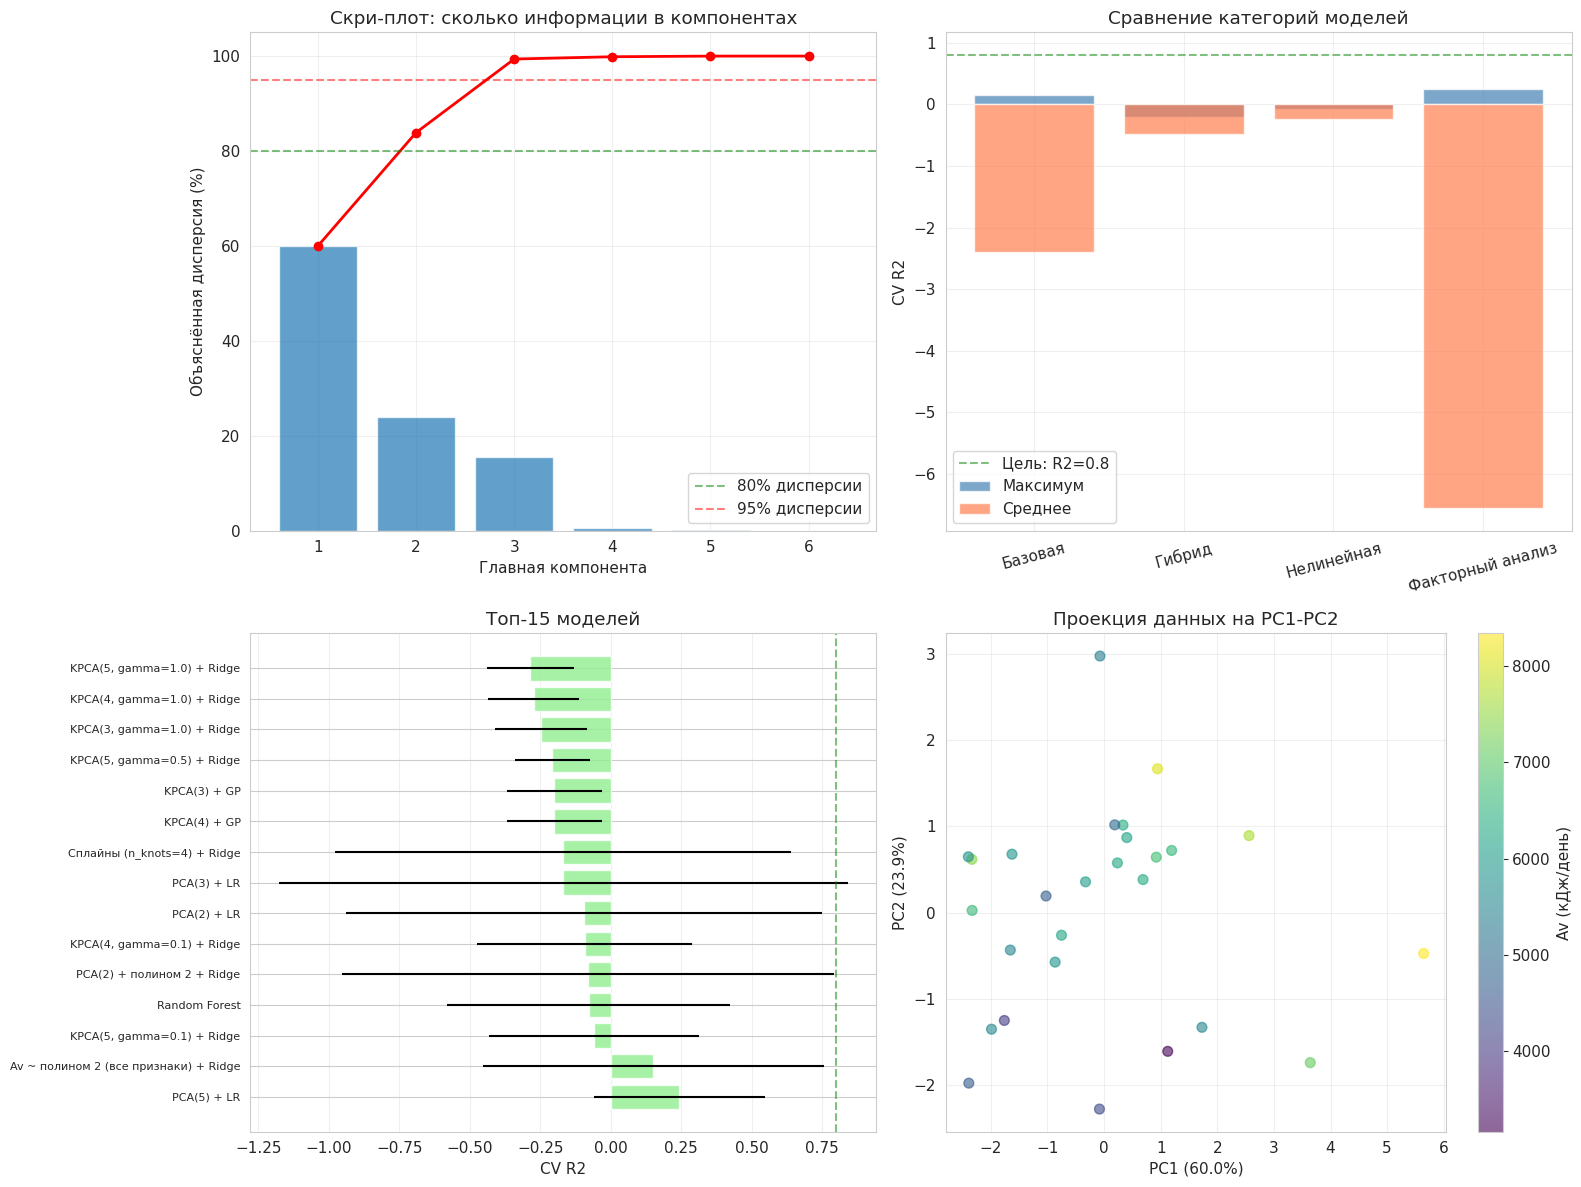


ВЫВОДЫ

Лучшая базовая модель: Av ~ полином 2 (все признаки) + Ridge
   CV R2 = 0.1515

Лучшая модель среди всех: PCA(5) + LR
   Категория: Факторный анализ
   CV R2 = 0.2436

Улучшение: +9.2%

R2 остаётся низким. Возможные причины:
   1. Данные действительно образуют сферу (нелинейная структура)
   2. Пропущены важные признаки
   3. Мало данных (нужно минимум 10x наблюдений на признак)
   4. Много шума в целевой переменной

Рекомендации:
   - Соберите больше данных (это самое главное!)
   - Добавьте физиологические признаки (возраст, VO2max, ЧСС)
   - Попробуйте UMAP/t-SNE для визуализации структуры
   - Используйте Gaussian Process - он лучше работает на малых данных

Результаты сохранены в factor_analysis_results.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
# Установка библиотек
!pip install openpyxl statsmodels scikit-learn sympy umap-learn > /dev/null 2>&1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, SplineTransformer
from sklearn.decomposition import PCA, KernelPCA
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ConstantKernel
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 8)
sns.set_style("whitegrid")
np.random.seed(42)

# ============================================================================
# 1. ЗАГРУЗКА ДАННЫХ
# ============================================================================
from google.colab import files
print("Загрузите Excel-файл:")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)
target = 'Av_kJ/day'
predictors_all = ['Body_length_cm', 'Body_weight_kg', 'OMT', 'Fat_kg', 'Fat_%', 'FFMI']

df_clean = df[[target] + predictors_all].dropna().copy()
X = df_clean[predictors_all].values
y = df_clean[target].values

print(f"Данные: {len(df_clean)} наблюдений, {X.shape[1]} признаков")

# ============================================================================
# 2. ДИАГНОСТИКА: ПОЧЕМУ R2 НИЗКИЙ?
# ============================================================================

print("\n" + "="*80)
print("ДИАГНОСТИКА СТРУКТУРЫ ДАННЫХ")
print("="*80)

# Стандартизация
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_scaled = (y - y.mean()) / y.std()

# PCA для анализа структуры
pca_full = PCA()
X_pca = pca_full.fit_transform(X_scaled)

print("\nДисперсия, объяснённая главными компонентами:")
cumulative = np.cumsum(pca_full.explained_variance_ratio_)
for i, (var, cum) in enumerate(zip(pca_full.explained_variance_ratio_, cumulative)):
    print(f"   PC{i+1}: {var*100:5.1f}%  (накопленная: {cum*100:5.1f}%)")

# Проверка "сферичности" через соотношение собственных значений
eigenvalues = pca_full.explained_variance_
print(f"\nСоотношение max/min собственных значений: {eigenvalues[0]/eigenvalues[-1]:.1f}")
print(f"Если это ~1 -> данные сферические")
print(f"Если это >> 1 -> данные вытянуты вдоль осей")

# Корреляция главных компонент с целевой переменной
print("\nКорреляция главных компонент с целевой переменной:")
for i in range(min(6, X_pca.shape[1])):
    corr = np.corrcoef(X_pca[:, i], y)[0, 1]
    print(f"   PC{i+1}: r = {corr:+.3f}")

# ============================================================================
# 3. БАЗОВЫЕ МОДЕЛИ (для сравнения)
# ============================================================================

print("\n" + "="*80)
print("БАЗОВЫЕ МОДЕЛИ (без факторного анализа)")
print("="*80)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_cv(model, X_data, y_data, name):
    """Кросс-валидация с R2"""
    scores = cross_val_score(model, X_data, y_data, cv=kf, scoring='r2')
    return {
        'name': name,
        'cv_R2_mean': scores.mean(),
        'cv_R2_std': scores.std()
    }

baseline_results = []

# Простая линейная на FFMI
m_base1 = LinearRegression()
res = evaluate_cv(m_base1, df_clean[['FFMI']].values, y, "Av ~ FFMI (линейная)")
baseline_results.append(res)
print(f"   {res['name']}: CV R2 = {res['cv_R2_mean']:.4f} (+/- {res['cv_R2_std']:.4f})")

# Множественная линейная (все признаки)
m_base2 = LinearRegression()
res = evaluate_cv(m_base2, X, y, "Av ~ все признаки (MLR)")
baseline_results.append(res)
print(f"   {res['name']}: CV R2 = {res['cv_R2_mean']:.4f} (+/- {res['cv_R2_std']:.4f})")

# Полином 2-й степени от всех признаков
m_base3 = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])
res = evaluate_cv(m_base3, X, y, "Av ~ полином 2 (все признаки) + Ridge")
baseline_results.append(res)
print(f"   {res['name']}: CV R2 = {res['cv_R2_mean']:.4f} (+/- {res['cv_R2_std']:.4f})")

# ============================================================================
# 4. ФАКТОРНЫЙ АНАЛИЗ: 4 ПОДХОДА
# ============================================================================

print("\n" + "="*80)
print("ФАКТОРНЫЙ АНАЛИЗ: 4 ПОДХОДА")
print("="*80)

fa_results = []

# ---------------------------------------------------------------------------
# ПОДХОД 1: PCA + линейная регрессия на компонентах
# ---------------------------------------------------------------------------
print("\n--- ПОДХОД 1: PCA + линейная регрессия ---")

for n_comp in [2, 3, 4, 5]:
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_comp)),
        ('lr', LinearRegression())
    ])
    res = evaluate_cv(model, X, y, f"PCA({n_comp}) + LR")
    fa_results.append(res)
    print(f"   PCA({n_comp}) + LR: CV R2 = {res['cv_R2_mean']:.4f}")

# ---------------------------------------------------------------------------
# ПОДХОД 2: PCA + полином 2-й степени на компонентах
# ---------------------------------------------------------------------------
print("\n--- ПОДХОД 2: PCA + полином 2-й степени ---")

for n_comp in [2, 3]:
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_comp)),
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('ridge', Ridge(alpha=1.0))
    ])
    res = evaluate_cv(model, X, y, f"PCA({n_comp}) + полином 2 + Ridge")
    fa_results.append(res)
    print(f"   PCA({n_comp}) + poly2 + Ridge: CV R2 = {res['cv_R2_mean']:.4f}")

# ---------------------------------------------------------------------------
# ПОДХОД 3: Kernel PCA (нелинейный факторный анализ)
# ---------------------------------------------------------------------------
print("\n--- ПОДХОД 3: Kernel PCA (RBF kernel) ---")

for n_comp in [3, 4, 5]:
    for gamma in [0.1, 0.5, 1.0]:
        model = Pipeline([
            ('scaler', StandardScaler()),
            ('kpca', KernelPCA(n_components=n_comp, kernel='rbf', gamma=gamma)),
            ('ridge', Ridge(alpha=1.0))
        ])
        try:
            res = evaluate_cv(model, X, y, f"KPCA({n_comp}, gamma={gamma}) + Ridge")
            fa_results.append(res)
            if res['cv_R2_mean'] > 0.5:
                print(f"   KPCA({n_comp}, gamma={gamma}): CV R2 = {res['cv_R2_mean']:.4f}")
        except:
            pass

# ---------------------------------------------------------------------------
# ПОДХОД 4: Автоэнкодер (нейросетевой нелинейный факторный анализ)
# ---------------------------------------------------------------------------
print("\n--- ПОДХОД 4: MLP (нейросеть как нелинейный факторный анализ) ---")

for hidden in [(4,), (8,), (16, 8)]:
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressor(hidden_layer_sizes=hidden, activation='relu',
                              max_iter=2000, random_state=42, early_stopping=True))
    ])
    try:
        res = evaluate_cv(model, X, y, f"MLP {hidden}")
        fa_results.append(res)
        print(f"   MLP {hidden}: CV R2 = {res['cv_R2_mean']:.4f}")
    except:
        pass

# ============================================================================
# 5. НЕЛИНЕЙНЫЕ МОДЕЛИ (для сравнения)
# ============================================================================

print("\n" + "="*80)
print("НЕЛИНЕЙНЫЕ МОДЕЛИ (без факторного анализа)")
print("="*80)

nonlinear_results = []

# Сплайны
model_spline = Pipeline([
    ('scaler', StandardScaler()),
    ('spline', SplineTransformer(n_knots=4, degree=3)),
    ('ridge', Ridge(alpha=1.0))
])
res = evaluate_cv(model_spline, X, y, "Сплайны (n_knots=4) + Ridge")
nonlinear_results.append(res)
print(f"   Сплайны: CV R2 = {res['cv_R2_mean']:.4f}")

# Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
res = evaluate_cv(rf, X, y, "Random Forest")
nonlinear_results.append(res)
print(f"   Random Forest: CV R2 = {res['cv_R2_mean']:.4f}")

# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=42)
res = evaluate_cv(gb, X, y, "Gradient Boosting")
nonlinear_results.append(res)
print(f"   Gradient Boosting: CV R2 = {res['cv_R2_mean']:.4f}")

# Gaussian Process
gp = Pipeline([
    ('scaler', StandardScaler()),
    ('gp', GaussianProcessRegressor(kernel=ConstantKernel(1.0) * RBF(1.0),
                                      alpha=1e-6, normalize_y=True))
])
res = evaluate_cv(gp, X, y, "Gaussian Process")
nonlinear_results.append(res)
print(f"   Gaussian Process: CV R2 = {res['cv_R2_mean']:.4f}")

# ============================================================================
# 6. ГИБРИДНЫЙ ПОДХОД: PCA + НЕЛИНЕЙНАЯ МОДЕЛЬ
# ============================================================================

print("\n" + "="*80)
print("ГИБРИД: PCA + НЕЛИНЕЙНАЯ МОДЕЛЬ")
print("="*80)

hybrid_results = []

for n_comp in [3, 4]:
    # PCA + Gradient Boosting
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_comp)),
        ('gb', GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=42))
    ])
    res = evaluate_cv(model, X, y, f"PCA({n_comp}) + GB")
    hybrid_results.append(res)
    print(f"   PCA({n_comp}) + GB: CV R2 = {res['cv_R2_mean']:.4f}")

    # Kernel PCA + GP
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('kpca', KernelPCA(n_components=n_comp, kernel='rbf', gamma=0.5)),
        ('gp', GaussianProcessRegressor(kernel=ConstantKernel(1.0) * RBF(1.0),
                                          alpha=1e-6, normalize_y=True))
    ])
    try:
        res = evaluate_cv(model, X, y, f"KPCA({n_comp}) + GP")
        hybrid_results.append(res)
        print(f"   KPCA({n_comp}) + GP: CV R2 = {res['cv_R2_mean']:.4f}")
    except:
        pass

# ============================================================================
# 7. СВОДНАЯ ТАБЛИЦА ВСЕХ РЕЗУЛЬТАТОВ
# ============================================================================

print("\n" + "="*80)
print("СВОДНАЯ ТАБЛИЦА: СРАВНЕНИЕ ВСЕХ ПОДХОДОВ")
print("="*80)

all_results = (
    [dict(r, category='Базовая') for r in baseline_results] +
    [dict(r, category='Факторный анализ') for r in fa_results] +
    [dict(r, category='Нелинейная') for r in nonlinear_results] +
    [dict(r, category='Гибрид') for r in hybrid_results]
)

results_df = pd.DataFrame(all_results).sort_values('cv_R2_mean', ascending=False)
print("\nТОП-20 ЛУЧШИХ МОДЕЛЕЙ:")
print(results_df.head(20).to_string(index=False))

# ============================================================================
# 8. ВИЗУАЛИЗАЦИЯ
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Дисперсия по компонентам
axes[0, 0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
                pca_full.explained_variance_ratio_ * 100, alpha=0.7)
axes[0, 0].plot(range(1, len(cumulative)+1), cumulative * 100, 'ro-', linewidth=2)
axes[0, 0].axhline(y=80, color='green', linestyle='--', alpha=0.5, label='80% дисперсии')
axes[0, 0].axhline(y=95, color='red', linestyle='--', alpha=0.5, label='95% дисперсии')
axes[0, 0].set_xlabel('Главная компонента')
axes[0, 0].set_ylabel('Объяснённая дисперсия (%)')
axes[0, 0].set_title('Скри-плот: сколько информации в компонентах')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Сравнение категорий моделей
category_stats = results_df.groupby('category')['cv_R2_mean'].agg(['mean', 'max', 'count'])
x_pos = range(len(category_stats))
axes[0, 1].bar(x_pos, category_stats['max'], alpha=0.7, color='steelblue', label='Максимум')
axes[0, 1].bar(x_pos, category_stats['mean'], alpha=0.7, color='coral', label='Среднее')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(category_stats.index, rotation=15)
axes[0, 1].set_ylabel('CV R2')
axes[0, 1].set_title('Сравнение категорий моделей')
axes[0, 1].axhline(y=0.8, color='green', linestyle='--', alpha=0.5, label='Цель: R2=0.8')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Топ-15 моделей
top15 = results_df.head(15)
axes[1, 0].barh(range(len(top15)), top15['cv_R2_mean'],
                xerr=top15['cv_R2_std'], color='lightgreen', alpha=0.8)
axes[1, 0].set_yticks(range(len(top15)))
axes[1, 0].set_yticklabels(top15['name'], fontsize=8)
axes[1, 0].set_xlabel('CV R2')
axes[1, 0].set_title('Топ-15 моделей')
axes[1, 0].axvline(x=0.8, color='green', linestyle='--', alpha=0.5)
axes[1, 0].grid(True, alpha=0.3, axis='x')

# 4. Проекция на первые 2 главные компоненты
scatter = axes[1, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis',
                              alpha=0.6, s=50)
plt.colorbar(scatter, ax=axes[1, 1], label='Av (кДж/день)')
axes[1, 1].set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}%)')
axes[1, 1].set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}%)')
axes[1, 1].set_title('Проекция данных на PC1-PC2')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('factor_analysis_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# 9. ВЫВОДЫ И РЕКОМЕНДАЦИИ
# ============================================================================

print("\n" + "="*80)
print("ВЫВОДЫ")
print("="*80)

best_model = results_df.iloc[0]
baseline_best = max(baseline_results, key=lambda x: x['cv_R2_mean'])

print(f"""
Лучшая базовая модель: {baseline_best['name']}
   CV R2 = {baseline_best['cv_R2_mean']:.4f}

Лучшая модель среди всех: {best_model['name']}
   Категория: {best_model['category']}
   CV R2 = {best_model['cv_R2_mean']:.4f}

Улучшение: {(best_model['cv_R2_mean'] - baseline_best['cv_R2_mean'])*100:+.1f}%
""")

if best_model['cv_R2_mean'] >= 0.8:
    print("ЦЕЛЬ ДОСТИГНУТА: R2 >= 0.8")
    print(f"Рекомендуемая модель: {best_model['name']}")
elif best_model['cv_R2_mean'] >= 0.7:
    print("Хороший результат: R2 >= 0.7")
    print("Для дальнейшего улучшения:")
    print("   - Добавьте новые признаки (возраст, пол, тренировочный стаж)")
    print("   - Соберите больше данных")
    print("   - Попробуйте UMAP или автоэнкодеры")
else:
    print("R2 остаётся низким. Возможные причины:")
    print("   1. Данные действительно образуют сферу (нелинейная структура)")
    print("   2. Пропущены важные признаки")
    print("   3. Мало данных (нужно минимум 10x наблюдений на признак)")
    print("   4. Много шума в целевой переменной")
    print("\nРекомендации:")
    print("   - Соберите больше данных (это самое главное!)")
    print("   - Добавьте физиологические признаки (возраст, VO2max, ЧСС)")
    print("   - Попробуйте UMAP/t-SNE для визуализации структуры")
    print("   - Используйте Gaussian Process - он лучше работает на малых данных")

# Сохраняем результаты
results_df.to_excel('factor_analysis_results.xlsx', index=False)
print("\nРезультаты сохранены в factor_analysis_results.xlsx")

files.download('factor_analysis_results.xlsx')
files.download('factor_analysis_results.png')

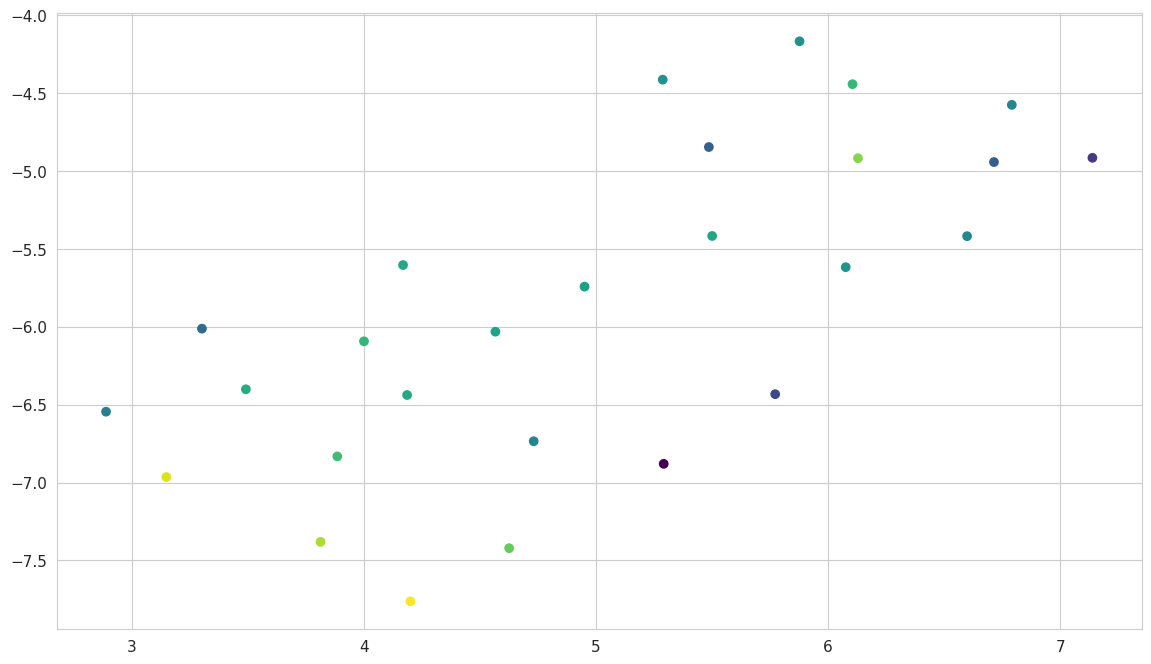

In [21]:
import umap
reducer = umap.UMAP(n_components=2)
X_umap = reducer.fit_transform(X_scaled)
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='viridis')